## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros a optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-10, fin=10`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado). Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para los 3 learning rates. Las 3 gráficas deben estar en el mismo plot para que la comparación visual sea más fácil.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
import seaborn as sns

$$
\text{Al tener una función de activación}  \tanh(z) \text{las derivadas nos quedarán}: 
$$

$$
\frac{\partial J}{\partial w} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat y_i) \frac{(x)}{cosh^{2}(wx+b)}\
$$

$$
\frac{\partial J}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat y_i)\frac{(1)}{cosh^{2}(wx+b)}\
$$

Pero sabiendo que: 

$$
cosh^{2}(z) - senh^{2}(z) = 1
$$

Podeos dividir todo por:
$$
cosh^{2}(z)
$$

Llegando a: 
$$
1 - \frac{senh^{2}(z)}{cosh^{2}(z)} = \frac{1}{cosh^{2}(z)}
$$
$$
1 - {tanh^{2}(z)} = \frac{1}{cosh^{2}(z)}
$$
$$
1 - {{\hat y}^{2}} = \frac{1}{cosh^{2}(z)}
$$

<p>Se opta por esta útlima forma de escribir el gradiente ya que conlleva dos beneficios:<li>Mayor simplicidad: no debemos usar la variable intermedia "z" dentro del código <li>Evitar errores matemáticos: utilzar "np.cosh" puede causar errores de overlfow</p>


In [ ]:
#Global Variables (will be reused on the other algorithms)

#Global Function defintions
def predict(W,B,X):
    """
    @fn:    predict
    @brief: calculates the y_hat vector of predictions
    @params: 
        W: weights | B: bias | X: input data 
    @returns: y_hat 
    """
    z = W*X+B 
    a = np.tanh(z)
    return a

def getCost(y,y_hat):
    """
    @fn:    getCost 
    @brief: calculates the cost function given a label and a prediction calculated by the model
    @params: 
        y: ground truth | y_hat: prediction
    @returns: loss 
    """
    
    return np.mean((y-y_hat)**2)


def dC_dZ(y,y_hat,X):
    """
    @fn:    dC_dZ
    @brief: computes the gradient of the loss function
    @params: 
        W: weights | B: bias
    @return dC_dW | dC_dB
    """

    n = len(X)

    #compute the error (only once) and store it into "err"
    err = (y-y_hat)


    #gradients with cosh:
    #dC_dW = np.sum(err * X/( (np.cosh(z))**2 ))
    #dC_dW = (-2/n)*(dC_dW)
    #dC_dB = np.sum(err/( (np.cosh(z))**2 ))
    #dC_dB = (-2/n)*(dC_dB)


    dC_dW = np.sum(err * X * (1-y_hat**2) )
    dC_dW = (-2/n)*(dC_dW)
    dC_dB = np.sum(err * (1-y_hat**2))
    dC_dB = (-2/n)*(dC_dB)

    return dC_dW,dC_dB

def non_lineal(X,noise,type):
    """
    @fn:    non_lineal
    @brief: non-lineal function to generate the ground truth from X
    @params: 
        X: dataset | type: type of function to apply
    @return y
    """
    if type=="polinomical":
        return (0.001)*X**3+(0.01)*X**2+(0.1)*X+noise
    if type=="sigmoid":
        return (1/(1+np.exp(-X)))+noise


In [553]:
#Data definition

ini = 5
end = -ini
dataset_size = 300
X = np.linspace(ini,end,dataset_size)

#instantieate random generator
seed = 14
rng = np.random.default_rng(seed=seed)


#generate ground truth
median = 0
deviation  = 0.1
noise = rng.normal(median,deviation,size=dataset_size) #in ML we usually model noise as a "Gaussian Noise"! 
y = non_lineal(X,noise,type="sigmoid")

<h2><b>Implementación Gradien Descent

In [ ]:
#train parameters
lrs = [0.1, 0.01, 0.001] #generate list with the learning rates
epochs = 100             #initialize epochs number
W0 = np.random.randn()   #generate random number to initialize the weights 
B0 = np.random.randn()   #generate random number to initialize the bias   


#initialize the parameters history arrays
path_w_GD = []
path_b_GD = []
path_C_GD = []
for _ in range(len(lrs)):
    path_w_GD.append([])
    path_b_GD.append([])
    path_C_GD.append([])



#implement the Gradient Descent Algorithm (GD): we have to do it for each lr
for i in range(len(lrs)):
    #get the lr 
    lr = lrs[i]
    
    #for each lr we re-initialize the parameters
    W = W0
    B = B0
    
    #obtain the predictions for the current set of parameters
    y_hat = predict(W,B,X)
        
    #compute the cost
    c = getCost(y,y_hat=y_hat)


    #store the first parameters values of this lr and epoch
    path_w_GD[i].append(W)
    path_b_GD[i].append(B)
    path_C_GD[i].append(c)

    #we compute all the epochs for each lr
    for epoch in range(epochs-1):

        #compute the gradient
        dC_dW,dC_dB = dC_dZ(y,y_hat,X)
        
        #update the parameters
        W = W - lr*dC_dW
        B = B - lr*dC_dB

        #obtain the predictions for the current set of parameters
        y_hat = predict(W,B,X)
        
        #compute the cost
        c = getCost(y,y_hat=y_hat)

        #store epoch values
        path_w_GD[i].append(W)
        path_b_GD[i].append(B)
        path_C_GD[i].append(c)


    

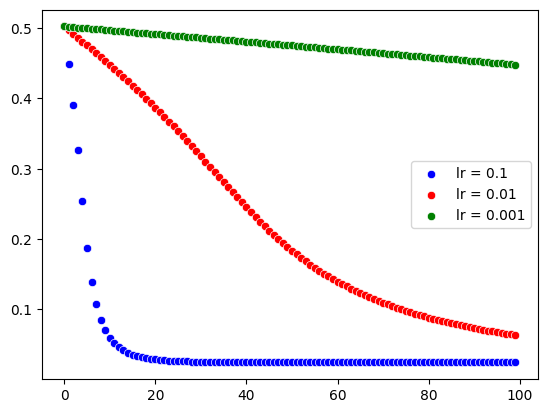

In [14]:
#2D loss graph
sns.scatterplot(x=np.arange(0,len(path_C_GD[0]),1),y=path_C_GD[0],label="lr = 0.1",color="blue")
sns.scatterplot(x=np.arange(0,len(path_C_GD[1]),1),y=path_C_GD[1],label="lr = 0.01",color="red")
sns.scatterplot(x=np.arange(0,len(path_C_GD[2]),1),y=path_C_GD[2],label="lr = 0.001",color="green")
plt.show()

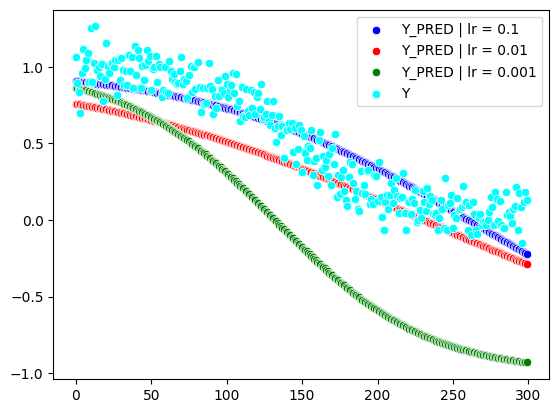

In [15]:
#lets check how we are aproximating the ground truth
Y_PRED_1 = np.tanh(path_w_GD[0][-1]*X+path_b_GD[0][-1])
Y_PRED_2 = np.tanh(path_w_GD[1][-1]*X+path_b_GD[1][-1])
Y_PRED_3 = np.tanh(path_w_GD[2][-1]*X+path_b_GD[2][-1])

sns.scatterplot(x=np.arange(0,len(Y_PRED_1),1),y=Y_PRED_1,label='Y_PRED | lr = 0.1',color='blue')
sns.scatterplot(x=np.arange(0,len(Y_PRED_2),1),y=Y_PRED_2,label='Y_PRED | lr = 0.01',color='red')
sns.scatterplot(x=np.arange(0,len(Y_PRED_3),1),y=Y_PRED_3,label='Y_PRED | lr = 0.001',color='green')
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan')

plt.show()

Podemos observar que el modelo con el lr mayor (0.1) fue el que más minimizó el costo y mejor se ajustó a la función objetivo. En principio, se podría haber esperado que un lr menor, fuera más performante, pero en realidad lo que sucede es que los lr menores aprenden más lento y al utilizar un número de épocas (relativamente) "bajo", estos modelos no tuvieron el tiempo suficiente para aprender.

### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno sin mini-batch (full-batch) y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

<h2><b>Implementación Adam Full-Batch

In [ ]:
#Function definition

#train parameters
beta_1 = 0.9
beta_2 = 0.999
epsilon = 1e-8
lrs = [0.1, 0.01, 0.001] #generate list with the learning rates
epochs = 100            #initialize epochs number
m_w = 0                   #initialize gradient median memory for the weights
m_b = 0                   #initialize gradient median memory for the biases
m_w_hat = 0               #initialize un-biased m_w
m_b_hat = 0               #initialize un-biased m_b
v_w = 0                   #initialize gradient^2 median for the weights
v_b = 0                   #initialize gradient^2 median for the biases
v_w_hat = 0               #initialize un-biased v_w
v_b_hat = 0               #initialize un-biased v_b

#W0 and B0 already initialized in DG 


#initialize the parameters history arrays
path_w_AFB = []
path_b_AFB = []
path_C_AFB = []
for _ in range(len(lrs)):
    path_w_AFB.append([])
    path_b_AFB.append([])
    path_C_AFB.append([])



#implement the ADAM Full batch (GD): we have to do it for each lr
for i in range(len(lrs)):
    #get the lr 
    lr = lrs[i]

    #re-initialize m and v
    m_w = 0                   #initialize gradient median memory for the weights
    m_b = 0                   #initialize gradient median memory for the biases
    m_w_hat = 0               #initialize un-biased m_w
    m_b_hat = 0               #initialize un-biased m_b
    v_w = 0                   #initialize gradient^2 median for the weights
    v_b = 0                   #initialize gradient^2 median for the biases
    v_w_hat = 0               #initialize un-biased v_w
    v_b_hat = 0               #initialize un-biased v_b
    
    #for each lr we re-initialize the parameters
    W = W0
    B = B0
    
    #obtain the predictions for the current set of parameters
    y_hat = predict(W,B,X)
        
    #compute the cost
    c = getCost(y,y_hat=y_hat)

    #calculate the first m_t and v_t
   # m_t = (1-beta_1)*c
   # v_t = (1-beta_2)*(c**2)

    #correct bias (TODO: check if neccessary on this step)
   # m_hat = (m_t)/((1-beta_1))
   # v_hat = (v_t)/(1-beta_2)

    #store the first parameters values of this lr and epoch
    path_w_AFB[i].append(W)
    path_b_AFB[i].append(B)
    path_C_AFB[i].append(c)

    #we compute all the epochs for each lr
    for epoch in range(1,epochs+1):
        
        #compute the gradient
        dC_dW,dC_dB = dC_dZ(y,y_hat,X)
        
        #calculate the first m_t and v_t
        m_w = beta_1*m_w+(1-beta_1)*dC_dW
        v_w = beta_2*v_w+(1-beta_2)*(dC_dW**2)
        m_b = beta_1*m_b+(1-beta_1)*dC_dB
        v_b = beta_2*v_b+(1-beta_2)*(dC_dB**2)        

        #correct bias
        m_w_hat = (m_w)/((1-(beta_1**epoch)))
        v_w_hat = (v_w)/(1-(beta_2**epoch))
        m_b_hat = (m_b)/((1-(beta_1**epoch)))
        v_b_hat = (v_b)/(1-(beta_2**epoch))

        #update the parameters
        W = W - lr*(m_w_hat/(np.sqrt(v_w_hat)+epsilon))
        B = B - lr*(m_b_hat/(np.sqrt(v_b_hat)+epsilon))

        #obtain the predictions for the current set of parameters
        y_hat = predict(W,B,X)
        
        #compute the cost
        c = getCost(y,y_hat=y_hat)

        #store epoch values
        path_w_AFB[i].append(W)
        path_b_AFB[i].append(B)
        path_C_AFB[i].append(c)


    

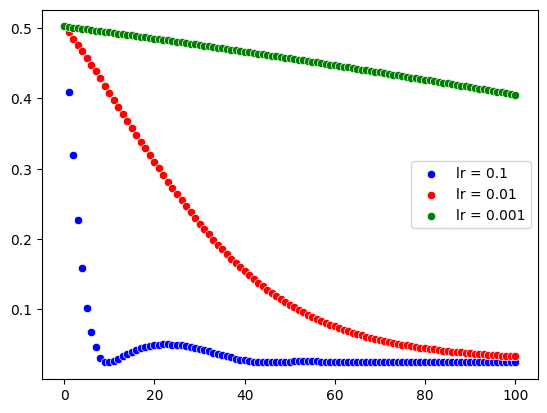

In [17]:
#2D loss graph
sns.scatterplot(x=np.arange(0,len(path_C_AFB[0]),1),y=path_C_AFB[0],label="lr = 0.1",color="blue")
sns.scatterplot(x=np.arange(0,len(path_C_AFB[1]),1),y=path_C_AFB[1],label="lr = 0.01",color="red")
sns.scatterplot(x=np.arange(0,len(path_C_AFB[2]),1),y=path_C_AFB[2],label="lr = 0.001",color="green")
plt.show()

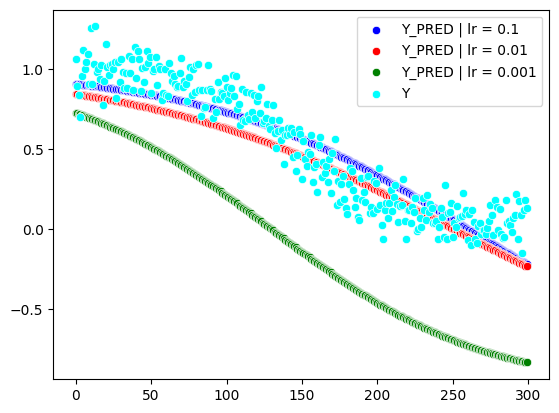

In [18]:
#lets check how we are aproximating the ground truth
Y_PRED_1 = np.tanh(path_w_AFB[0][-1]*X+path_b_AFB[0][-1])
Y_PRED_2 = np.tanh(path_w_AFB[1][-1]*X+path_b_AFB[1][-1])
Y_PRED_3 = np.tanh(path_w_AFB[2][-1]*X+path_b_AFB[2][-1])

sns.scatterplot(x=np.arange(0,len(Y_PRED_1),1),y=Y_PRED_1,label='Y_PRED | lr = 0.1',color='blue')
sns.scatterplot(x=np.arange(0,len(Y_PRED_2),1),y=Y_PRED_2,label='Y_PRED | lr = 0.01',color='red')
sns.scatterplot(x=np.arange(0,len(Y_PRED_3),1),y=Y_PRED_3,label='Y_PRED | lr = 0.001',color='green')
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan')

plt.show()

<h2><b>Implementación Adam Mini-Batch

In [ ]:
#train parameters
beta_1 = 0.9
beta_2 = 0.999
epsilon = 1e-8
lrs = [0.1, 0.01, 0.001] #generate list with the learning rates
epochs = 100            #initialize epochs number
m_w = 0                   #initialize gradient median memory for the weights
m_b = 0                   #initialize gradient median memory for the biases
m_w_hat = 0               #initialize un-biased m_w
m_b_hat = 0               #initialize un-biased m_b
v_w = 0                   #initialize gradient^2 median for the weights
v_b = 0                   #initialize gradient^2 median for the biases
v_w_hat = 0               #initialize un-biased v_w
v_b_hat = 0               #initialize un-biased v_b
batch_size = 75

if (len(X)%batch_size) == 0:
    batches = int(len(X)/batch_size)
else:
    batches = int((len(X)/batch_size))+1

#W0 and B0 already initialized in DG 


#initialize the parameters history arrays
path_w_AMB= []
path_b_AMB= []
path_C_AMB= []
for _ in range(len(lrs)):
    path_w_AMB.append([])
    path_b_AMB.append([])
    path_C_AMB.append([])



#implement the ADAM Full batch (GD): we have to do it for each lr
for i in range(len(lrs)):
    #get the lr 
    lr = lrs[i]

    #re-initialize m and v
    m_w = 0                   #initialize gradient median memory for the weights
    m_b = 0                   #initialize gradient median memory for the biases
    m_w_hat = 0               #initialize un-biased m_w
    m_b_hat = 0               #initialize un-biased m_b
    v_w = 0                   #initialize gradient^2 median for the weights
    v_b = 0                   #initialize gradient^2 median for the biases
    v_w_hat = 0               #initialize un-biased v_w
    v_b_hat = 0               #initialize un-biased v_b
    
    #for each lr we re-initialize the parameters
    W = W0
    B = B0
    
    #keep track of the actualizations (we can't use "epochs" as in Adam Full-Batch)
    t = 0



    x_batch = X[0:batch_size]
    y_batch = y[0:batch_size]

    #obtain the first prediction and cost 
    y_hat = predict(W,B,x_batch)

    #compute the cost
    c = getCost(y_batch,y_hat=y_hat)   
    
    #store epoch values
    path_w_AMB[i].append(W)
    path_b_AMB[i].append(B)
    path_C_AMB[i].append(c)

    #we compute all the epochs for each lr
    for epoch in range(1,epochs+1):
    
        for batch in range(2,batches+1):
            t+=1

            
            #compute the gradient
            dC_dW,dC_dB = dC_dZ(y_batch,y_hat,x_batch)
            
            #calculate the first m_t and v_t
            m_w = beta_1*m_w+(1-beta_1)*dC_dW
            v_w = beta_2*v_w+(1-beta_2)*(dC_dW**2)
            m_b = beta_1*m_b+(1-beta_1)*dC_dB
            v_b = beta_2*v_b+(1-beta_2)*(dC_dB**2)        

            #correct bias
            m_w_hat = (m_w)/((1-(beta_1**t)))
            v_w_hat = (v_w)/(1-(beta_2**t))
            m_b_hat = (m_b)/((1-(beta_1**t)))
            v_b_hat = (v_b)/(1-(beta_2**t))

            #update the parameters
            W = W - lr*(m_w_hat/(np.sqrt(v_w_hat)+epsilon))
            B = B - lr*(m_b_hat/(np.sqrt(v_b_hat)+epsilon))

            #obtain the batches for the iteration
            x_batch = X[batch_size*(batch-1):batch_size*batch]
            y_batch = y[batch_size*(batch-1):batch_size*batch]

            #obtain the predictions for the current set of parameters
            y_hat = predict(W,B,x_batch)
            
            #compute the cost
            c = getCost(y_batch,y_hat=y_hat)


        #store epoch values
        path_w_AMB[i].append(W)
        path_b_AMB[i].append(B)
        path_C_AMB[i].append(c)




    

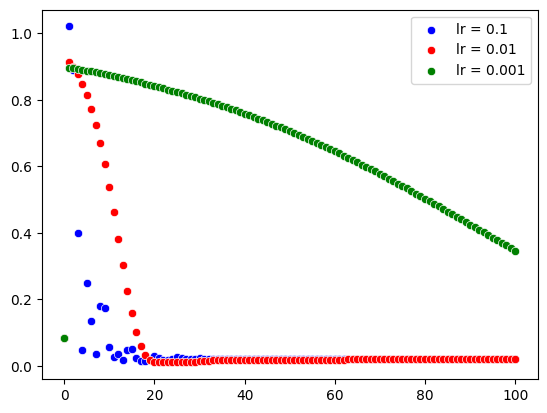

In [20]:
#2D loss graph
sns.scatterplot(x=np.arange(0,len(path_C_AMB[0]),1),y=path_C_AMB[0],label="lr = 0.1",color="blue")
sns.scatterplot(x=np.arange(0,len(path_C_AMB[1]),1),y=path_C_AMB[1],label="lr = 0.01",color="red")
sns.scatterplot(x=np.arange(0,len(path_C_AMB[2]),1),y=path_C_AMB[2],label="lr = 0.001",color="green")
plt.show()

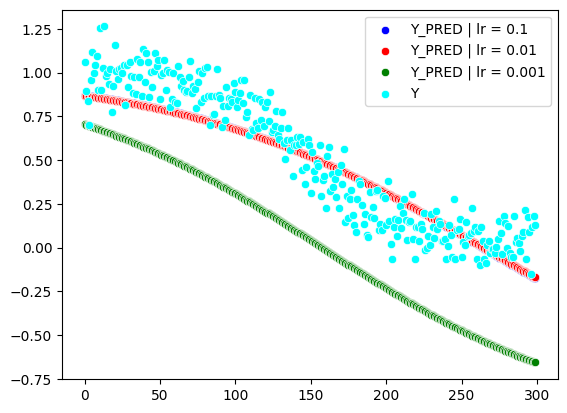

In [21]:
#lets check how we are aproximating the ground truth
Y_PRED_1 = np.tanh(path_w_AMB[0][-1]*X+path_b_AMB[0][-1])
Y_PRED_2 = np.tanh(path_w_AMB[1][-1]*X+path_b_AMB[1][-1])
Y_PRED_3 = np.tanh(path_w_AMB[2][-1]*X+path_b_AMB[2][-1])

sns.scatterplot(x=np.arange(0,len(Y_PRED_1),1),y=Y_PRED_1,label='Y_PRED | lr = 0.1',color='blue')
sns.scatterplot(x=np.arange(0,len(Y_PRED_2),1),y=Y_PRED_2,label='Y_PRED | lr = 0.01',color='red')
sns.scatterplot(x=np.arange(0,len(Y_PRED_3),1),y=Y_PRED_3,label='Y_PRED | lr = 0.001',color='green')
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan')

plt.show()

### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes.

<h2>Comparativas de evolución del costo

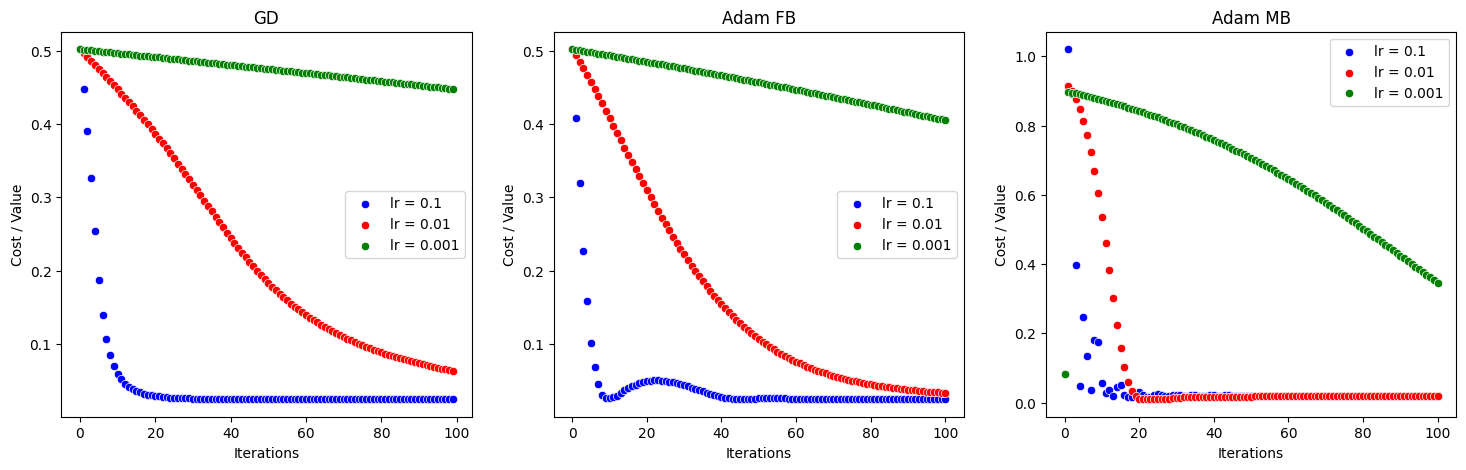

In [28]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))


#2D loss graph
sns.scatterplot(x=np.arange(0,len(path_C_GD[0]),1),y=path_C_GD[0],label="lr = 0.1",color="blue",ax=ax1)
sns.scatterplot(x=np.arange(0,len(path_C_GD[1]),1),y=path_C_GD[1],label="lr = 0.01",color="red",ax=ax1)
sns.scatterplot(x=np.arange(0,len(path_C_GD[2]),1),y=path_C_GD[2],label="lr = 0.001",color="green",ax=ax1)
ax1.set_title("GD")
ax1.set_xlabel("Iterations")
ax1.set_ylabel("Cost / Value")

sns.scatterplot(x=np.arange(0,len(path_C_AFB[0]),1),y=path_C_AFB[0],label="lr = 0.1",color="blue",ax=ax2)
sns.scatterplot(x=np.arange(0,len(path_C_AFB[1]),1),y=path_C_AFB[1],label="lr = 0.01",color="red",ax=ax2)
sns.scatterplot(x=np.arange(0,len(path_C_AFB[2]),1),y=path_C_AFB[2],label="lr = 0.001",color="green",ax=ax2)
ax2.set_title("Adam FB")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("Cost / Value")

sns.scatterplot(x=np.arange(0,len(path_C_AMB[0]),1),y=path_C_AMB[0],label="lr = 0.1",color="blue")
sns.scatterplot(x=np.arange(0,len(path_C_AMB[1]),1),y=path_C_AMB[1],label="lr = 0.01",color="red")
sns.scatterplot(x=np.arange(0,len(path_C_AMB[2]),1),y=path_C_AMB[2],label="lr = 0.001",color="green")
ax3.set_title("Adam MB")
ax3.set_xlabel("Iterations")
ax3.set_ylabel("Cost / Value")

plt.show()

<h2>Comparativas modelos

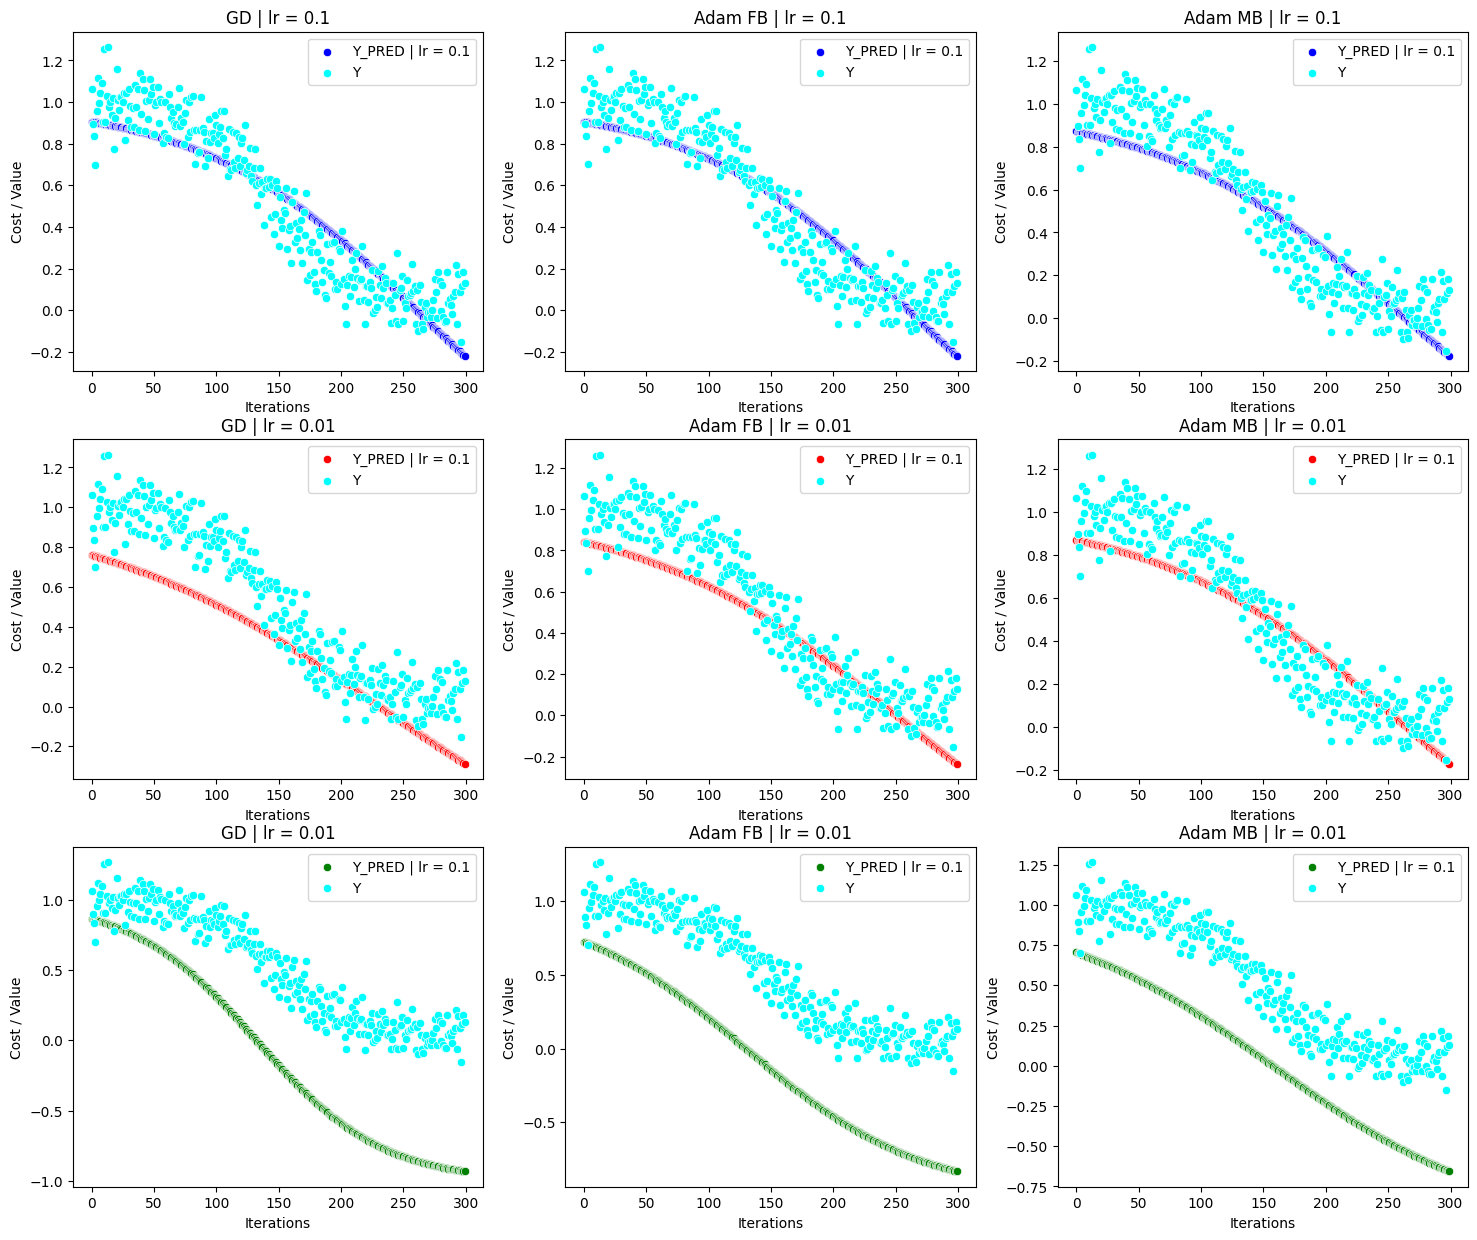

In [36]:
fig, ((ax1, ax2, ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(3, 3, figsize=(18, 15))

#GD
Y_PRED_1_GD = np.tanh(path_w_GD[0][-1]*X+path_b_GD[0][-1])
Y_PRED_2_GD = np.tanh(path_w_GD[1][-1]*X+path_b_GD[1][-1])
Y_PRED_3_GD = np.tanh(path_w_GD[2][-1]*X+path_b_GD[2][-1])

#AFB
Y_PRED_1_AFB = np.tanh(path_w_AFB[0][-1]*X+path_b_AFB[0][-1])
Y_PRED_2_AFB = np.tanh(path_w_AFB[1][-1]*X+path_b_AFB[1][-1])
Y_PRED_3_AFB = np.tanh(path_w_AFB[2][-1]*X+path_b_AFB[2][-1])

#AMB
Y_PRED_1_AMB = np.tanh(path_w_AMB[0][-1]*X+path_b_AMB[0][-1])
Y_PRED_2_AMB = np.tanh(path_w_AMB[1][-1]*X+path_b_AMB[1][-1])
Y_PRED_3_AMB = np.tanh(path_w_AMB[2][-1]*X+path_b_AMB[2][-1])

#Plots

#lr = 0.1
sns.scatterplot(x=np.arange(0,len(Y_PRED_1_GD),1),y=Y_PRED_1_GD,label='Y_PRED | lr = 0.1',color='blue',ax=ax1)
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan',ax=ax1)
ax1.set_title("GD | lr = 0.1")
ax1.set_xlabel("Iterations")
ax1.set_ylabel("Cost / Value")
sns.scatterplot(x=np.arange(0,len(Y_PRED_1_AFB),1),y=Y_PRED_1_AFB,label='Y_PRED | lr = 0.1',color='blue',ax=ax2)
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan',ax=ax2)
ax2.set_title("Adam FB | lr = 0.1")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("Cost / Value")
sns.scatterplot(x=np.arange(0,len(Y_PRED_1_AMB),1),y=Y_PRED_1_AMB,label='Y_PRED | lr = 0.1',color='blue',ax=ax3)
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan',ax=ax3)
ax3.set_title("Adam MB | lr = 0.1")
ax3.set_xlabel("Iterations")
ax3.set_ylabel("Cost / Value")


#lr = 0.01
sns.scatterplot(x=np.arange(0,len(Y_PRED_2_GD),1),y=Y_PRED_2_GD,label='Y_PRED | lr = 0.1',color='red',ax=ax4)
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan',ax=ax4)
ax4.set_title("GD | lr = 0.01")
ax4.set_xlabel("Iterations")
ax4.set_ylabel("Cost / Value")
sns.scatterplot(x=np.arange(0,len(Y_PRED_2_AFB),1),y=Y_PRED_2_AFB,label='Y_PRED | lr = 0.1',color='red',ax=ax5)
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan',ax=ax5)
ax5.set_title("Adam FB | lr = 0.01")
ax5.set_xlabel("Iterations")
ax5.set_ylabel("Cost / Value")
sns.scatterplot(x=np.arange(0,len(Y_PRED_2_AMB),1),y=Y_PRED_2_AMB,label='Y_PRED | lr = 0.1',color='red',ax=ax6)
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan',ax=ax6)
ax6.set_title("Adam MB | lr = 0.01")
ax6.set_xlabel("Iterations")
ax6.set_ylabel("Cost / Value")


#lr = 0.001
sns.scatterplot(x=np.arange(0,len(Y_PRED_3_GD),1),y=Y_PRED_3_GD,label='Y_PRED | lr = 0.1',color='green',ax=ax7)
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan',ax=ax7)
ax7.set_title("GD | lr = 0.01")
ax7.set_xlabel("Iterations")
ax7.set_ylabel("Cost / Value")
sns.scatterplot(x=np.arange(0,len(Y_PRED_3_AFB),1),y=Y_PRED_3_AFB,label='Y_PRED | lr = 0.1',color='green',ax=ax8)
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan',ax=ax8)
ax8.set_title("Adam FB | lr = 0.01")
ax8.set_xlabel("Iterations")
ax8.set_ylabel("Cost / Value")
sns.scatterplot(x=np.arange(0,len(Y_PRED_3_AMB),1),y=Y_PRED_3_AMB,label='Y_PRED | lr = 0.1',color='green',ax=ax9)
sns.scatterplot(x=np.arange(0,len(y),1),y=y,label='Y',color='cyan',ax=ax9)
ax9.set_title("Adam MB | lr = 0.01")
ax9.set_xlabel("Iterations")
ax9.set_ylabel("Cost / Value")



plt.show()

<br>Como se comentara anteriormente, una constante que podemos entre los tres modelos es que la cantidad de épocas, pareciera no ser suficiente para que un lr = 0.001 nos sea suficiente para entrenar un modelo que pueda ajustarse a la función propuesta</br>
<br>Podemos observar para el caso del Adam mini-batch, para el lr = 0.1 la dispersión de valores de costo que tenemos al principio del entrenamiento. Este compartamiento, resulta propio de este algoritmo en que, la dirección y módulo del gradiente, puede diferir entre cada mini-batch. El efecto se minimiza para lr más pequeños, en los que vemos que la curva de descenso del costo, toma una forma mucho más suave</br> 
<br>Con los algoritmos Adam, nos sería posible utilizar un lr menor (0.01). Esto podría ser una ventaja, dado que lr "grandes" podrían ocasionar que se den pasos tan grandes, que no se llegue a la zona de mínimo coste (aunque no pareciera ser el caso en nuestra prueba, podría ser por el tipo de función elegida y el tamaño del batch) </br>

### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia.

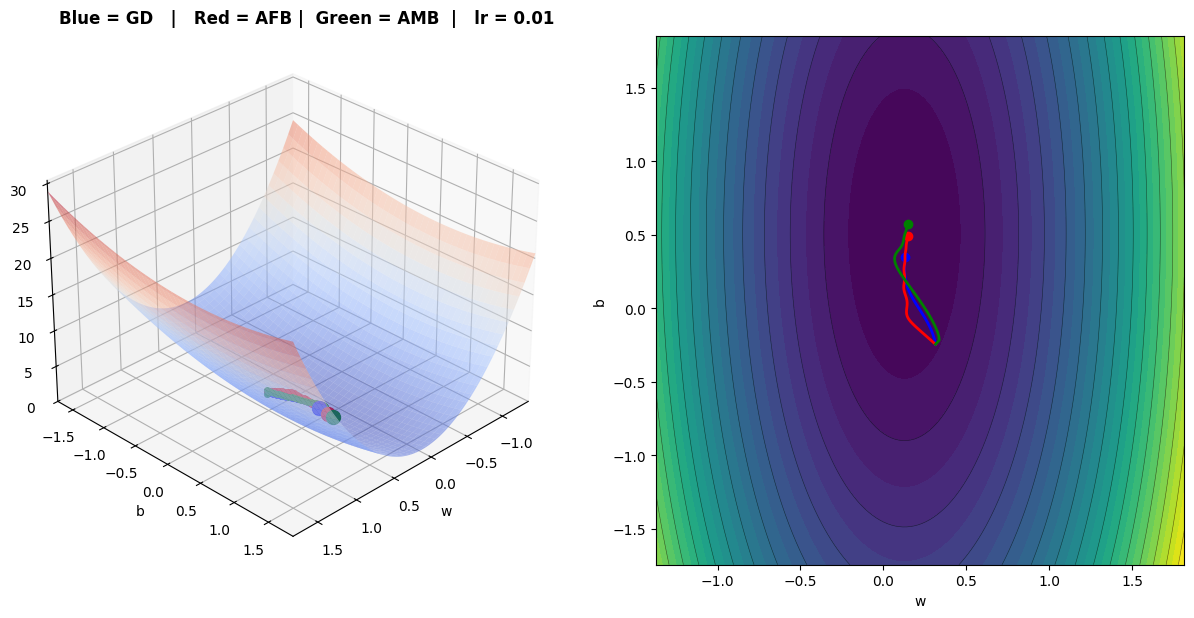

In [554]:
#set the lr
lr = 0.01
i = lrs.index(lr)

#we create numpy arrays from our parameters lists for each algorithm
path_w_gd = np.array(path_w_GD[i])
path_b_gd = np.array(path_b_GD[i])
path_J_gd = np.array(path_C_GD[i])

path_w_afb = np.array(path_w_AFB[i])
path_b_afb = np.array(path_b_AFB[i])
path_J_afb = np.array(path_C_AFB[i])

path_w_amb = np.array(path_w_AMB[i])
path_b_amb = np.array(path_b_AMB[i])
path_J_amb = np.array(path_C_AMB[i])



# GRÁFICAS Y ANIMACIONES:
# --- Malla de la superficie del costo ---
pad_w, pad_b = 1.5, 1.5

#para graficar la superficie de costo, debo calcular mi función de costo para un rango de valores más amplio que los w y b que realmente obtuve (si no, sólo vería una línea en el espacio)
wmin, wmax = min(path_w_gd.min(), W0) - pad_w, max(path_w_gd.max(), W0) + pad_w
bmin, bmax = min(path_b_gd.min(), B0) - pad_b, max(path_b_gd.max(), B0) + pad_b

#obtenemos los vectores W y B, que van desde el mínimo w y b, hasta los máximos que usaré para graficar
W = np.linspace(wmin, wmax, 140)
B = np.linspace(bmin, bmax, 140)
#calculamos el meshgrid: esto nos permite utilizar nuestros vectores 1D W y B, para conformar una grilla (al estilo, "tablero de ajedrez") y conformar un plano 2D
WW, BB = np.meshgrid(W, B)
#definimmos un costo
JJ = np.zeros_like(WW)
#calculamos la función de costo para todos los puntos de nuestra grilla, para poder su superficie graficar
for i in range(WW.shape[0]):
    yhat_grid = WW[i][None, :] * X[:, None] + BB[i][None, :]
    JJ[i] = np.mean((y[:, None] - yhat_grid) ** 2, axis=0)


#generamos gráfico en 3D de la superficie de costo
fig = plt.figure(figsize=(15, 15))
ax3d = fig.add_subplot(1, 2, 1, projection="3d")
ax2d = fig.add_subplot(1, 2, 2)
surf = ax3d.plot_surface(WW, BB, JJ, alpha=0.5, linewidth=0, antialiased=True,cmap="coolwarm")

ax3d.view_init(elev=30, azim=45)
ax3d.set_xlim(wmin, wmax)
ax3d.set_ylim(bmin, bmax)
ax3d.set_zlim(0, JJ.max() * 1.05) 

#trazamos sobre la superficie, el camino recorido para cada algoritmo
ax3d.plot(path_w_gd, path_b_gd, path_J_gd, color='blue', marker='o', markersize=4, linewidth=2, label='Recorrido (W, B, Z)')
ax3d.scatter(path_w_gd[-1], path_b_gd[-1],path_J_gd[-1], color='blue', s=100, label='Mínimo alcanzado') # Destacar el final

ax3d.plot(path_w_afb, path_b_afb, path_J_afb, color='red', marker='o', markersize=4, linewidth=2, label='Recorrido (W, B, Z)')
ax3d.scatter(path_w_afb[-1], path_b_afb[-1],path_J_afb[-1], color='red', s=100, label='Mínimo alcanzado') # Destacar el final

ax3d.plot(path_w_amb, path_b_amb, path_J_amb, color='green', marker='o', markersize=4, linewidth=2, label='Recorrido (W, B, Z)')
ax3d.scatter(path_w_amb[-1], path_b_amb[-1],path_J_amb[-1], color='green', s=100, label='Mínimo alcanzado') # Destacar el final

fig.text(        0.15, 0.68,
        f"Blue = GD   |   Red = AFB |  Green = AMB  |   lr = {lr}",
        fontsize=12, weight="bold")
ax3d.set_xlabel("w")
ax3d.set_ylabel("b")
ax3d.set_zlabel("J(w,b)")


cs = ax2d.contourf(WW, BB, JJ, levels=30)
ax2d.contour(WW, BB, JJ, levels=15, colors="k", linewidths=0.4, alpha=0.6)
ax2d.plot(path_w_gd, path_b_gd, lw=2, color="blue")
ax2d.plot(path_w_gd[-1], path_b_gd[-1], marker="o", markersize=6, color="blue")

ax2d.plot(path_w_afb, path_b_afb, lw=2, color="red")
ax2d.plot(path_w_afb[-1], path_b_afb[-1], marker="o", markersize=6, color="red")

ax2d.plot(path_w_amb, path_b_amb, lw=2, color="green")
ax2d.plot(path_w_amb[-1], path_b_amb[-1], marker="o", markersize=6, color="green")
ax2d.set_xlabel("w")
ax2d.set_ylabel("b")
ax2d.set_xlim(wmin, wmax)
ax2d.set_ylim(bmin, bmax)
ax2d.set_box_aspect((1))


plt.show()

<br>Podemos observar cómo los modelos sufrieron desplazamientos distintos sobre la superficie de costo. Con el modelo adam full batch, se encuentra un camino directo y rápido hacia el punto mínimo. En comparación, para el modelo de gradient descent, el movimiento hacia el valle (o hacia un punto medio de la superficie) es mucho más lento y no llega a un punto tan óptimo como el Adam full-batch. Por último, el Adam mini-batch sigue un camino muy similar al GD, pero llegándo inluso a excederse en algún punto de lo que hubiera sido el camino más óptimo y tampoco llega al mínimo (lo que puede suceder en este tipo de algoritmos)</br>

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual.


### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.

In [73]:
import pandas as pd

In [78]:
df = pd.read_csv(r'dataset_compras.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     182721 non-null  int64  
 1   Product_ID                  182721 non-null  str    
 2   Age                         182721 non-null  str    
 3   Gender                      182721 non-null  str    
 4   Marital_Status              182721 non-null  int64  
 5   City_Category               182721 non-null  str    
 6   Stay_In_Current_City_Years  182721 non-null  str    
 7   Product_Category            182721 non-null  int64  
 8   Product_Subcategory_1       140903 non-null  float64
 9   Product_Subcategory_2       77461 non-null   float64
 10  Purchase                    182721 non-null  int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 15.3 MB


Observamos que tenemos dos columnas "Product_Subcategory_1" y "Product_Subcategory_2" que poseen valores nulos

In [96]:
Product_Subcategory_2_NaN_Count = len(df[df["Product_Subcategory_2"].notna()==False])
df_size = len(df)
nan_ratio = Product_Subcategory_2_NaN_Count/df_size*100
print(f"{nan_ratio:.2f}% of the Product_Subcategory_2 column are NaN values")

57.61% of the Product_Subcategory_2 column are NaN values


<br>Como podemos observar, más de la mitad de los valores de la columna "Product_Subcategory_2" son NaN. Con lo cuál, esta columna realmente no nos está aportando información considerable: <b>se procederá a quitarla del data frame</b></br>

In [97]:
df.drop(columns=["Product_Subcategory_2"],inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     182721 non-null  int64  
 1   Product_ID                  182721 non-null  str    
 2   Age                         182721 non-null  str    
 3   Gender                      182721 non-null  str    
 4   Marital_Status              182721 non-null  int64  
 5   City_Category               182721 non-null  str    
 6   Stay_In_Current_City_Years  182721 non-null  str    
 7   Product_Category            182721 non-null  int64  
 8   Product_Subcategory_1       140903 non-null  float64
 9   Purchase                    182721 non-null  int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 13.9 MB


Si conducimos el mismo análisis para la columna "Product_Subcategory_1", el resultado será distinto, dada la cantidad de registros con información que poseemos

In [99]:
Product_Subcategory_1_NaN_Count = len(df[df["Product_Subcategory_1"].notna()==False])
df_size = len(df)
nan_ratio = Product_Subcategory_1_NaN_Count/df_size*100
print(f"{nan_ratio:.2f}% of the Product_Subcategory_1 column are NaN values")

22.89% of the Product_Subcategory_1 column are NaN values


Un 23% aproximadamente de los valores de la columna son nulos. Si los quitaramos, aún conservaríamos en nuestro dataset 140.903 registros con información valiosa. Se evaluará más adelante si estos casos son salvables y puede trabajarse el todos los registros

<br>Revisaremos cuántos registros por cliente tenemos. Dado que no nos interesa predecir por cada transacción sino por cliente, si tenemos más de un registro por cliente, deberemos proceder a "compactar" el dataset; es decir: generar un nuevo dataset que posea una única entrada por cliente</br>

In [ ]:
#group registers by "User_ID" and make a "count" operation
df_grouped_by_user = df.groupby(by="User_ID",as_index=False)
df_grouped_by_user.size().head(10).sort_values(by="size",ascending=False)

,User_ID,size
6,1000134,49
1,1000044,43
2,1000070,42
3,1000087,41
7,1000135,36
9,1000149,17
4,1000115,17
5,1000127,16
0,1000035,13
8,1000142,13


<br>Efectivamente, poseemos más de un registro por persona, con lo cuál deberemos compactar el dataset y generar nuevos features "totalizadores" (o indicadores) que pueden ser medidos por User_ID; siempre con la precaución de no producir un Data leakage

In [105]:
df.head(10)

,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,7142
5,1047008,P00024740,18-25,M,0,A,2,5,16.0,353
6,1056762,P00067925,46-50,F,1,B,5+,17,24.0,117
7,1047329,P00003426,36-45,F,1,B,1,16,NaN,447
8,1042051,P00074117,46-50,F,1,B,5+,11,20.0,7831
9,1032071,P00039594,51-55,F,1,B,4,3,NaN,704


Generaremos la columa target: 

In [134]:
#generate target column "medium_spent"
means = df_grouped_by_user["Purchase"].mean()
#rename means.purchase to means.medium_spent
means.rename(columns={'Purchase': 'medium_spent'},inplace=True)
means.head(10)


,User_ID,medium_spent
0,1000035,1912.923077
1,1000044,14338.906977
2,1000070,4120.809524
3,1000087,11228.219512
4,1000115,4673.882353
5,1000127,1764.062500
6,1000134,5405.448980
7,1000135,13646.277778
8,1000142,3081.461538
9,1000149,5928.529412


In [ ]:
#merge the new column into our original DataFrame
df = pd.merge(df,means,how="inner", on="User_ID")

<br>En este punto ya tenemos generada nuestra variable target.</br>

Veamos ahora el resto de las variables que tenemos en nuestro dataframe

In [142]:
df.head(10)

,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Purchase,medium_spent
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,1810,6895.142857
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,12351,4666.857143
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,127,11071.771429
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,2214,13216.360000
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,7142,8613.562500
5,1047008,P00024740,18-25,M,0,A,2,5,16.0,353,870.200000
6,1056762,P00067925,46-50,F,1,B,5+,17,24.0,117,12819.305556
7,1047329,P00003426,36-45,F,1,B,1,16,NaN,447,7192.000000
8,1042051,P00074117,46-50,F,1,B,5+,11,20.0,7831,7648.545455
9,1032071,P00039594,51-55,F,1,B,4,3,NaN,704,5228.682927


<br><b>Variables categóricas:</b>
    <ul>
        <li><i>Gender:</i> Esta columa podríamos aplicarle un one-hot encoding, ya que podríamos mantener la misma cantidad de columnas haciendo esto. Por ejemplo, podríamos crear la columna "Male", con valores 0 y 1.</li>
        <li><i>City_Category: Aplicamos un label encoding, ya que podemos observar un orden entre las categorías</i></li>
        <li><i>Product_ID: Código identificador del cliente, no aporta en sí información útil. Se descarta</i></li>
        <li><i>Age: Aplicamos label encoding ya que podemos observar un oriden lógico entre las categorías</i></li>
        <li><i>Marital_Status: Ya se encuentra codificada en One-Hot</i></li>
        <li><i>User_ID:</i> el user ID es un código identificador del usuario que no aporta información alguna al problema</li>
        <li><i>Stay_In_Current_City_Years:</i> el user ID es un código identificador del usuario que no aporta información alguna al problema</li>
    </ul>
</br>

<h3>Tratamiento de variable "Gender"

In [148]:
#verify for unique values on Gender
df["Gender"].unique()

<StringArray>
['F', 'M']
Length: 2, dtype: str

In [ ]:
#Generate new Column "Male"
df['Male']  = (df['Gender'] == 'M').astype(int)
df.head(15)

,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Purchase,medium_spent,Male
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,1810,6895.142857,0
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,12351,4666.857143,1
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,127,11071.771429,1
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,2214,13216.360000,1
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,7142,8613.562500,1
5,1047008,P00024740,18-25,M,0,A,2,5,16.0,353,870.200000,1
6,1056762,P00067925,46-50,F,1,B,5+,17,24.0,117,12819.305556,0
7,1047329,P00003426,36-45,F,1,B,1,16,NaN,447,7192.000000,0
8,1042051,P00074117,46-50,F,1,B,5+,11,20.0,7831,7648.545455,0
9,1032071,P00039594,51-55,F,1,B,4,3,NaN,704,5228.682927,0


In [ ]:
#Drop the Gender column
df.drop(columns="Gender",inplace=True)

<h3>Tratamiento de variable "Gender"

In [ ]:
#Check unique values for city category
df["City_Category"].unique()

<StringArray>
['B', 'A', 'C']
Length: 3, dtype: str

<br>Vemos que las ciudades en las que viven los usuarios, se han clasificado en tres tipo: A, B y C. En principio, podríamos pensar que existe alguna relación entre esta clasificación y lo que un usuario gasta en promedio por año (distintas ciudades, pueden tener distintos nivels socioecomicos en promedio, ser más periféricas o poseer mayor actividad industrial y comercial).</br><br>Una manera de verificar esto, puede ser obteniendo el gasto agrupado por ciudad:

In [157]:
df.groupby(by="City_Category",as_index=False)["Purchase"].sum()

,City_Category,Purchase
0,A,652160697
1,B,461421466
2,C,321082643


In [ ]:
df_ciudades = df.groupby(by="City_Category",as_index=False).size().rename(columns={'size': 'sales_nbr'})

,City_Category,size
0,A,76169
1,B,60097
2,C,46455


<br>Lo que observamos es que <b>en las ciudades de categoría "A" se compra más y se gasta más. Esto deciende de manera ordenada hasta la categoría "C".</br>

<br>Si hicieramos una codificación one hot, estaríamos agregando dos columnas a nuestro dataset y además asumiendo que existe una equidistancia entre cada clase (lo cuál en este caso, no podemos saber). Por otro lado, un ordinal-encoding, si bien en general no resulta recomendable porque implica asumir un orden lógico entre las clases, en este caso no pareciera ser un enfoque errado: vemos que las clases de ciudad pueden ordenarse según un criterio que podríamos llamar de "poder adquisitivo"</br> 

In [166]:
#@fn:       encode_city
#@brief:    applies a label encoding to the City_Ctegory label
#@params:   row
#return:    label
def encode_city(row):
    category = row["City_Category"]
    if category=="A":
        return 2
    elif category=="B":
        return 1
    elif category=="C":
        return 0

In [167]:
#apply the label ecoding to the city category
df["encoded_city"] = df.apply(encode_city,axis=1)
df.head(10)

,User_ID,Product_ID,Age,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Purchase,medium_spent,Male,encoded_city
0,1044096,P00017122,46-50,1,B,1,10,45.0,1810,6895.142857,0,1
1,1071818,P00074517,36-45,0,A,3,11,27.0,12351,4666.857143,1,2
2,1022986,P00013694,36-45,1,A,5+,4,28.0,127,11071.771429,1,2
3,1094684,P00049122,36-45,1,A,1,16,9.0,2214,13216.360000,1,2
4,1004157,P00006469,46-50,1,A,5+,3,NaN,7142,8613.562500,1,2
5,1047008,P00024740,18-25,0,A,2,5,16.0,353,870.200000,1,2
6,1056762,P00067925,46-50,1,B,5+,17,24.0,117,12819.305556,0,1
7,1047329,P00003426,36-45,1,B,1,16,NaN,447,7192.000000,0,1
8,1042051,P00074117,46-50,1,B,5+,11,20.0,7831,7648.545455,0,1
9,1032071,P00039594,51-55,1,B,4,3,NaN,704,5228.682927,0,1


In [168]:
#we drop the original "City_Category" column
df.drop(columns="City_Category",inplace=True)

<h3>Tratamiento de Age

<br>En el caso de la variable "Age", tenemos un orden lógico a seguir: "18-25", es menor que "46-50". Por lo tanto, podemos también aplicar un ordinal encoding.

In [173]:
#check all the unique labels for "Age"
df["Age"].unique()

<StringArray>
['46-50', '36-45', '18-25', '51-55', '55+', '26-35', '0-17']
Length: 7, dtype: str

In [174]:
#@fn:       encode_age
#@brief:    applies a label encoding to the Age label
#@params:   row
#return:    label
def encode_age(row):
    category = row["Age"]
    if category=="55+":
        return 6
    elif category=="51-55":
        return 5
    elif category=="46-50":
        return 4
    elif category=="36-45":
        return 3
    elif category=="26-35":
        return 2
    elif category=="18-25":
        return 1
    elif category=="0-17":
        return 0

In [175]:
df["encoded_age"] = df.apply(encode_age,axis=1)
df.head(10)

,User_ID,Product_ID,Age,Marital_Status,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Purchase,medium_spent,Male,encoded_city,encoded_age
0,1044096,P00017122,46-50,1,1,10,45.0,1810,6895.142857,0,1,4
1,1071818,P00074517,36-45,0,3,11,27.0,12351,4666.857143,1,2,3
2,1022986,P00013694,36-45,1,5+,4,28.0,127,11071.771429,1,2,3
3,1094684,P00049122,36-45,1,1,16,9.0,2214,13216.360000,1,2,3
4,1004157,P00006469,46-50,1,5+,3,NaN,7142,8613.562500,1,2,4
5,1047008,P00024740,18-25,0,2,5,16.0,353,870.200000,1,2,1
6,1056762,P00067925,46-50,1,5+,17,24.0,117,12819.305556,0,1,4
7,1047329,P00003426,36-45,1,1,16,NaN,447,7192.000000,0,1,3
8,1042051,P00074117,46-50,1,5+,11,20.0,7831,7648.545455,0,1,4
9,1032071,P00039594,51-55,1,4,3,NaN,704,5228.682927,0,1,5


In [176]:
df.drop(columns="Age",inplace=True)

<h3>Tratamiento de Product_Category

<br>Podemos utilizar la variable "Product_Category" para obtener una moda por usuario de qué categoría de producto fue la que más a comprado

In [187]:
user_mode = df_grouped_by_user["Product_Category"].agg(pd.Series.mode)
user_mode

,User_ID,Product_Category
0,1000035,16
1,1000044,18
2,1000070,16
3,1000087,20
4,1000115,"[3, 4, 10, 15]"
...,...,...
7427,1099930,"[4, 16]"
7428,1099936,10
7429,1099948,3
7430,1099974,3


<br>Vemos que existen casos de empate en la moda (como el caso del User_ID = 1000115).

Para poder desempatar, se eligirá la categoría que sea globalmente más común

In [ ]:
#we generate a Global Counter for each Product_Category
category_count = df.groupby("Product_Category",as_index=False).size().rename(columns={"size":"Category_Global_Count"})
category_count

,Product_Category,Category_Global_Count
0,1,6261
1,2,4032
2,3,19950
3,4,7764
4,5,8889
5,6,6070
6,7,5979
7,8,8796
8,9,7408
9,10,14068


In [ ]:
#compute the amout of buys by user by Product_Category
category_by_user = df.groupby(by=["User_ID","Product_Category"],as_index=False).size()
category_by_user

,User_ID,Product_Category,size
0,1000035,5,2
1,1000035,7,1
2,1000035,9,1
3,1000035,10,3
4,1000035,15,1
...,...,...,...
86825,1099995,16,2
86826,1099995,17,2
86827,1099995,18,4
86828,1099995,19,3


In [205]:
#merge the two auxiliary tables onto one
mode_by_user = pd.merge(category_by_user,category_count,on="Product_Category",how="inner")

In [ ]:
#sort the "merged" DataFrame so we keep for each user the category he most buyed, and in case of tie, we keep with the more globaly buyed
mode_by_user = mode_by_user.sort_values(by=["size","Category_Global_Count"],ascending=False).drop_duplicates(subset="User_ID",keep="first")

In [207]:
#drop the auxiliary columns. We keep the mode column, se we have mode for each User_ID
mode_by_user.drop(columns=["size","Category_Global_Count"],inplace=True)
mode_by_user.rename(columns={"Product_Category":"mode"},inplace=True)
mode_by_user

,User_ID,mode
13835,1015635,3
28425,1032782,3
82318,1094823,3
3068,1003357,3
21962,1025157,3
...,...,...
66272,1076192,3
3335,1003686,10
44752,1051487,10
63232,1072500,10


In [ ]:
#We add the "mode" column to the DataFrame
df = pd.merge(df,mode_by_user,how="inner",on="User_ID")

Finalmente, teniendo nuestra columna moda agregada al dataframe, dropeamos la columna Product_Category

In [211]:
df.drop(columns="Product_Category",inplace=True)
df

,User_ID,Product_ID,Marital_Status,Stay_In_Current_City_Years,Product_Subcategory_1,Purchase,medium_spent,Male,encoded_city,encoded_age,mode
0,1044096,P00017122,1,1,45.0,1810,6895.142857,0,1,4,3
1,1071818,P00074517,0,3,27.0,12351,4666.857143,1,2,3,12
2,1022986,P00013694,1,5+,28.0,127,11071.771429,1,2,3,3
3,1094684,P00049122,1,1,9.0,2214,13216.360000,1,2,3,3
4,1004157,P00006469,1,5+,NaN,7142,8613.562500,1,2,4,3
...,...,...,...,...,...,...,...,...,...,...,...
182716,1024684,P00058904,1,1,39.0,21830,13982.911111,1,2,3,3
182717,1002745,P00085227,1,3,32.0,558,4654.714286,0,0,5,10
182718,1084548,P00039244,1,4,NaN,308,12600.888889,0,1,4,3
182719,1030878,P00003658,1,3,36.0,3401,11869.386364,0,1,4,3


<br>Hemos generado nuestra columna "mode" (moda), pero en realidad sigue siendo categórica</br>

In [322]:

print(f"There are {len(df["mode"].unique())} different values for Product Category 'mode' ")

There are 20 different values for Product Category 'mode' 


<br>Renombramos la columna moda a "most_purchased_category" y, como no es una variable cateogórica ordinal, la codificaremos con un One-Hot encoding

In [ ]:
df.rename(columns={"mode":"most_purchased_category"},inplace=True)
df = pd.get_dummies(df, columns=['most_purchased_category'],drop_first=False,dtype=int)
df.columns()

In [333]:
#Drop one of the One-Hot encoded columns
df.drop(columns="most_purchased_category_20",inplace=True)

In [334]:
df.head(5)

,User_ID,Product_ID,Marital_Status,Product_Subcategory_1,Purchase,medium_spent,Male,encoded_city,encoded_age,years_in_city_encoded,...,most_purchased_category_10,most_purchased_category_11,most_purchased_category_12,most_purchased_category_13,most_purchased_category_14,most_purchased_category_15,most_purchased_category_16,most_purchased_category_17,most_purchased_category_18,most_purchased_category_19
0,1044096,P00017122,1,45.0,1810,6895.142857,0,1,4,1,...,0,0,0,0,0,0,0,0,0,0
1,1071818,P00074517,0,27.0,12351,4666.857143,1,2,3,3,...,0,0,1,0,0,0,0,0,0,0
2,1022986,P00013694,1,28.0,127,11071.771429,1,2,3,5,...,0,0,0,0,0,0,0,0,0,0
3,1094684,P00049122,1,9.0,2214,13216.360000,1,2,3,1,...,0,0,0,0,0,0,0,0,0,0
4,1004157,P00006469,1,0.0,7142,8613.562500,1,2,4,5,...,0,0,0,0,0,0,0,0,0,0


<h3>Tratamieto de Product_Subcategory_1

In [ ]:
df2 = pd.read_csv(r'dataset_compras.csv')

<br>Se intentará verificar si los casos en que "Product Subcategory 1" no posee valor, corresponde a productos que no poseen sub-producto en ningún caso. Si fuera así, los valores NaN podrían rellenarse con 0, indicando que no hay subproducto

In [235]:
#Obtanin the Product_ID list of every record that has NaN in Product_Subcategory_1
products_no_subcategory =  df2[df2["Product_Subcategory_1"].isna()==True]["Product_ID"].unique()

In [236]:
df2[df2["Product_ID"].isin(products_no_subcategory)]["Product_Subcategory_1"].unique()

array([nan])

<br>Vemos que todos los casos de producos que encontramos que poseen algún registro con Product_Subcategory_1 en "NaN", poseen todos sus registros con "Product_Subcategory_1" en NaN. Por lo tanto, podemos compeltar con 0

In [237]:
#delete the auxiliary dataframe
del df2

In [240]:
df["Product_Subcategory_1"] = df["Product_Subcategory_1"].fillna(0)

<br>Para esta columna, podríamos generar una columna de moda igual que hicimos con categoría, pero codificar en One-Hot nos agregaría varias columnas (sumadas a las que ya hemos generado con la codificacón de la categoría de producto). En principio, para no generar más features, no consideraremos esta columna

In [337]:
df.drop(columns="Product_Subcategory_1",inplace=True)

<h3>Tratamiento de Stay_In_Current_City_Years

In [ ]:
#check if there are users with more than one City_Category
a = df_grouped_by_user.apply(lambda x: x['City_Category'].unique())
a.rename(columns={None:"city_cat_by_user"},inplace=True)
#obtain the lenght of each list that is in "city_cat_by_user"
a['city_cat_by_user'] = a['city_cat_by_user'].apply(lambda x : len(x))
#Print the results
print(f"We have {len(a[a['city_cat_by_user']>1])} users with more than one city category") 

We have 0 users with more than one city category


In [ ]:
#delete auxiliary dataframe
del a

<br>Como vemos, no tenemos usuarios que posean más de una categoría de ciudad asociada</br><br>Como establecimos anteriormente, la catagoría de ciudad, tiene relación con la cantidad de compras y con la suma que se gasta. Con lo cuál, podíamos pensar que un usuario que lleva más tiempo en su categoría de ciudad, habrá gastado más que otro que lleva menos (aunque en realidad, dependería de la cantidad de compras que ha realizado y de qué artículos. Puede que una persona que lleva muchos años en la ciudad, pero compró poco, haya gastado menos que alguien que lleva poco tiempo pero compró mucho)</br>

In [290]:
spent_by_city_years = df.groupby(by="Stay_In_Current_City_Years",as_index=False)["Purchase"].sum()
spent_by_city_years

,Stay_In_Current_City_Years,Purchase
0,1,297811331
1,2,266930624
2,3,224778705
3,4,323767117
4,5+,321377029


In [289]:
#evolution of sales grouped by Yers in current city
sales_by_city_years =    df.groupby(by="Stay_In_Current_City_Years",as_index=False).size()
sales_by_city_years

,Stay_In_Current_City_Years,size
0,1,41481
1,2,38445
2,3,25620
3,4,38820
4,5+,38355


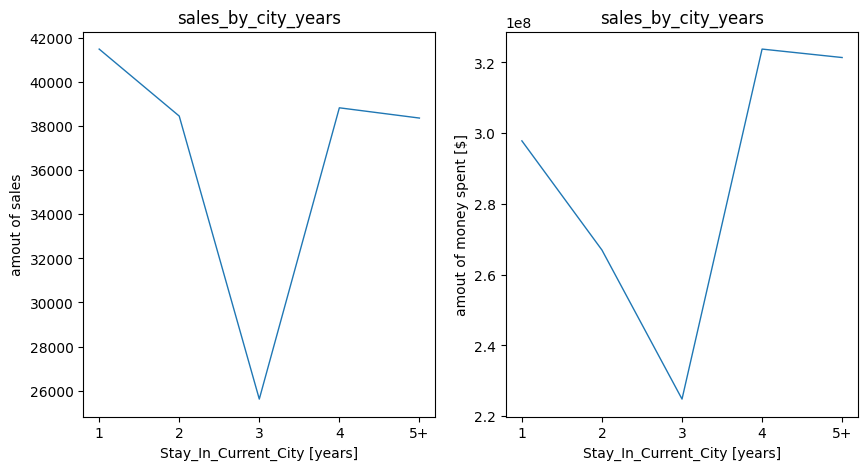

In [303]:
#plot sales_by_city_years
fig = plt.figure(figsize=(10, 5))
fig1 = fig.add_subplot(1,2,1)
fig2 = fig.add_subplot(1,2,2)
fig1.plot(sales_by_city_years["Stay_In_Current_City_Years"], sales_by_city_years["size"], linewidth=1)
fig2.plot(spent_by_city_years["Stay_In_Current_City_Years"], spent_by_city_years["Purchase"], linewidth=1)
fig1.set_title("sales_by_city_years")
fig1.set_xlabel("Stay_In_Current_City [years]")
fig1.set_ylabel("amout of sales")
fig2.set_title("sales_by_city_years")
fig2.set_xlabel("Stay_In_Current_City [years]")
fig2.set_ylabel("amout of money spent [$]")
plt.show()

<br>Lo que podemos obserar es que, la relación entre estar más tiempo en una ciudad y gastar o comprar más, no es lineal: más tiempo, no significa más compras. Los usuarios, compran mucho apenas llegan y luego sus compras decrecen, para volver a a aumentar en el cuarto año (esto puede tener relación con los tipos de productos que vende la tienda; ej.: podrían ser productos para el hogar que la gente compra una vez y cambia sólo luego de ciertos años). Como lo que tenemos luego es "5+" años, donde agrupamos mucha cantidad de años, no podemos decir mucho de lo que sucede después. Sin embargo, vemos que sí nos es una variable útil para obtener información acerca de lo que un usuario puede llegar a gastar. Dado que existe un orden lógico entre los años, podemos realizar una codificación del tipo: 1,2,3,4,5</br>

In [ ]:
#apply codification to "Stay_In_Current_City_Years"
df["years_in_city_encoded"] = df["Stay_In_Current_City_Years"].apply(lambda x : "5" if x=="5+" else x)
df["years_in_city_encoded"] = pd.to_numeric(df['years_in_city_encoded'])

In [316]:
df.drop(columns="Stay_In_Current_City_Years",inplace=True)

In [338]:
pd.set_option('display.max_columns', None)
df

,User_ID,Product_ID,Marital_Status,Purchase,medium_spent,Male,encoded_city,encoded_age,years_in_city_encoded,most_purchased_category_1,most_purchased_category_2,most_purchased_category_3,most_purchased_category_4,most_purchased_category_5,most_purchased_category_6,most_purchased_category_7,most_purchased_category_8,most_purchased_category_9,most_purchased_category_10,most_purchased_category_11,most_purchased_category_12,most_purchased_category_13,most_purchased_category_14,most_purchased_category_15,most_purchased_category_16,most_purchased_category_17,most_purchased_category_18,most_purchased_category_19
0,1044096,P00017122,1,1810,6895.142857,0,1,4,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1071818,P00074517,0,12351,4666.857143,1,2,3,3,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2,1022986,P00013694,1,127,11071.771429,1,2,3,5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1094684,P00049122,1,2214,13216.360000,1,2,3,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1004157,P00006469,1,7142,8613.562500,1,2,4,5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182716,1024684,P00058904,1,21830,13982.911111,1,2,3,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
182717,1002745,P00085227,1,558,4654.714286,0,0,5,3,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
182718,1084548,P00039244,1,308,12600.888889,0,1,4,4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
182719,1030878,P00003658,1,3401,11869.386364,0,1,4,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<h3>Tratamiento de Purchase, Product_ID y User_ID

<ul>
    <li>Purchase: esta es una varible por compra. Nosotros lo que deseamos es compactar el dataset y generar un registro por <i>usuario</i>. Por lo tanto, no podemos conservarla. Podríamos obtener alguna métrica más, como el máximo que el usuario a gastado (o el mínimo)</li>
    <li>Product_ID: es un código identificador de producto, no nos aporta en sí información (ya hemos obtenido un dato de producto, al codificar el tipo más comprado por el usuario)</li>
    <li>User_ID: es un código identificador del usuario, no posee información valiosa. Eliminaremos la columna como último paso</li>
</ul>

In [349]:
maximun_purchase = df_grouped_by_user["Purchase"].max()
maximun_purchase.rename(columns={"Purchase":"max_purchase"},inplace=True)
df = pd.merge(df,maximun_purchase,on="User_ID",how="inner")
del maximun_purchase
df.head(10)

,User_ID,Product_ID,Marital_Status,Purchase,medium_spent,Male,encoded_city,encoded_age,years_in_city_encoded,most_purchased_category_1,most_purchased_category_2,most_purchased_category_3,most_purchased_category_4,most_purchased_category_5,most_purchased_category_6,most_purchased_category_7,most_purchased_category_8,most_purchased_category_9,most_purchased_category_10,most_purchased_category_11,most_purchased_category_12,most_purchased_category_13,most_purchased_category_14,most_purchased_category_15,most_purchased_category_16,most_purchased_category_17,most_purchased_category_18,most_purchased_category_19,max_purchase
0,1044096,P00017122,1,1810,6895.142857,0,1,4,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13640
1,1071818,P00074517,0,12351,4666.857143,1,2,3,3,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,19450
2,1022986,P00013694,1,127,11071.771429,1,2,3,5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29920
3,1094684,P00049122,1,2214,13216.360000,1,2,3,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29660
4,1004157,P00006469,1,7142,8613.562500,1,2,4,5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28570
5,1047008,P00024740,0,353,870.200000,1,2,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,3396
6,1056762,P00067925,1,117,12819.305556,0,1,4,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,29980
7,1047329,P00003426,1,447,7192.000000,0,1,3,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,27490
8,1042051,P00074117,1,7831,7648.545455,0,1,4,5,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,25570
9,1032071,P00039594,1,704,5228.682927,0,1,5,4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25480


In [350]:
df.drop(columns=["Product_ID","Purchase"],inplace=True)
df

,User_ID,Marital_Status,medium_spent,Male,encoded_city,encoded_age,years_in_city_encoded,most_purchased_category_1,most_purchased_category_2,most_purchased_category_3,most_purchased_category_4,most_purchased_category_5,most_purchased_category_6,most_purchased_category_7,most_purchased_category_8,most_purchased_category_9,most_purchased_category_10,most_purchased_category_11,most_purchased_category_12,most_purchased_category_13,most_purchased_category_14,most_purchased_category_15,most_purchased_category_16,most_purchased_category_17,most_purchased_category_18,most_purchased_category_19,max_purchase
0,1044096,1,6895.142857,0,1,4,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13640
1,1071818,0,4666.857143,1,2,3,3,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,19450
2,1022986,1,11071.771429,1,2,3,5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29920
3,1094684,1,13216.360000,1,2,3,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29660
4,1004157,1,8613.562500,1,2,4,5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182716,1024684,1,13982.911111,1,2,3,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29920
182717,1002745,1,4654.714286,0,0,5,3,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,20640
182718,1084548,1,12600.888889,0,1,4,4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29390
182719,1030878,1,11869.386364,0,1,4,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29870


In [357]:
#we compact the dataframe, to get a new dataframe that only has une user per record
df_compact = df.drop_duplicates(subset=['User_ID'], keep='first')
df_compact = df_compact.reset_index(drop=True)
df_compact.drop(columns="User_ID",inplace=True)
df_compact

,Marital_Status,medium_spent,Male,encoded_city,encoded_age,years_in_city_encoded,most_purchased_category_1,most_purchased_category_2,most_purchased_category_3,most_purchased_category_4,most_purchased_category_5,most_purchased_category_6,most_purchased_category_7,most_purchased_category_8,most_purchased_category_9,most_purchased_category_10,most_purchased_category_11,most_purchased_category_12,most_purchased_category_13,most_purchased_category_14,most_purchased_category_15,most_purchased_category_16,most_purchased_category_17,most_purchased_category_18,most_purchased_category_19,max_purchase
0,1,6895.142857,0,1,4,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13640
1,0,4666.857143,1,2,3,3,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,19450
2,1,11071.771429,1,2,3,5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29920
3,1,13216.360000,1,2,3,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29660
4,1,8613.562500,1,2,4,5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7427,1,7796.400000,0,0,5,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,23080
7428,0,5576.100000,1,1,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,28440
7429,1,6681.250000,0,1,4,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,28060
7430,1,10629.800000,0,0,5,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,26310


<h3>Verificación de correlación

<br>Al realizar una correlación, vemos que no existe una variable en nuestro DataFrame que posea una alta <b>correlación lineal</b> con el target. Pero sí podemos tener relaciones no lineales</br>

<h3>Armado del dataset

In [ ]:
X = df_compact.drop(columns="medium_spent")

#store "y" single column dataframe
y = df_compact[["medium_spent"]]

### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

In [364]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

<br>En principio plantearemos para nuestro modelo: 
<ul>
    <li><i>Función activación:</i> ReLU</li>
    <li><i>Función de costo:</i>   MSE</li>
    <li><i>Algortimo de optimización:</i>  Adam Ful-Batch</li>
    <li><i>Learning rate:</i>  0.1 </li>
</ul>

In [401]:
#if GPU is available, use GPU, if not CPU (in this machine, we don't have GPU, but we leave this in case the notebook is executed )
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#convert out dataframes to torch tensors
X_tensor = torch.tensor(X.to_numpy(),dtype=torch.float32)
y_tensor = torch.tensor(y.to_numpy(),dtype=torch.float32)


#Split out dataset on Train and test
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.25, random_state=42)
X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)

#define number of input neurons
input_neurons = len(X.columns)

In [ ]:
#def define_model(lr,epochs)

In [ ]:
#Model definition
#as a start, we use ReLU activation function. We can change it later on, if the results are not good enough
model = nn.Sequential(
    #input layer
    nn.Linear(input_neurons, 32),
    nn.ReLU(),
    #hiden layer #1
    nn.Linear(32, 64),
    nn.ReLU(),
    #hiden layer #2
    nn.Linear(64, 64),
    nn.ReLU(),
    #hiden layer #3
    nn.Linear(64, 32),
    nn.ReLU(),
    #Output layer
    nn.Linear(32, 1),
).to(device)

#define lr
lr = 0.01
#define batch size (for full batch, equals number of sambles)
batch_size = len(X)
#set epochs number
epochs = 30

ds = TensorDataset(X_train, y_train)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

#set optimization funcion to Adam
opt = torch.optim.Adam(model.parameters(), lr=lr)
#set loss function (MSE). Pytorch doesn't have RMSLoss function implemented
mse_loss = nn.MSELoss()

In [396]:
#Model training

#set model in train mode
model.train()

#list to plot the evolution of the model
loss_hist = []
r2_hist = []
i = 0

#epoch loop
for epoch in range(epochs):
    epoch_loss = 0
    #batch loop
    for xb, yb in dl:
        i+=1
        #forward step
        yhat = model(xb)
        #compute the RMSE with our ground truht and our predicted data
        loss = torch.sqrt(mse_loss(yhat, yb)) 

        #reset gradient
        opt.zero_grad(set_to_none=True)
        #set starting point for the backpropagation (we start from the error value, and go backwards from there)
        loss.backward()
        #variable (ws and bs) actualization
        opt.step()
        #accumulate all the epoch loss
        epoch_loss += loss.item()

    #compute the mean epoch loss and store it for plot later
    epoch_loss /= len(dl)
    loss_hist.append(epoch_loss)

    # Compute R² by epoch
    model.eval()
    with torch.no_grad():
        yhat_test = model(X_test)
        y_true_np = y_test.view(-1).cpu().numpy()
        y_pred_np = yhat_test.view(-1).cpu().numpy()
        r2 = r2_score(y_true_np, y_pred_np)
        r2_hist.append(r2)
    model.train()

#set model to eval, and get the score and eval loss
model.eval()
with torch.no_grad():
    yhat = model(X_test)
    mse = mse_loss(yhat, y_test).item()
    rmse = mse ** 0.5
    y_true_np = y_test.view(-1).cpu().numpy()
    y_pred_np = yhat.view(-1).cpu().numpy()
    r2 = r2_score(y_true_np, y_pred_np)

print(f"Adam full-batch with torch.nn  RMSE={rmse:.4f}  R2={r2:.4f}  device={device}")

Adam full-batch with torch.nn  RMSE=2560.6477  R2=0.4087  device=cpu


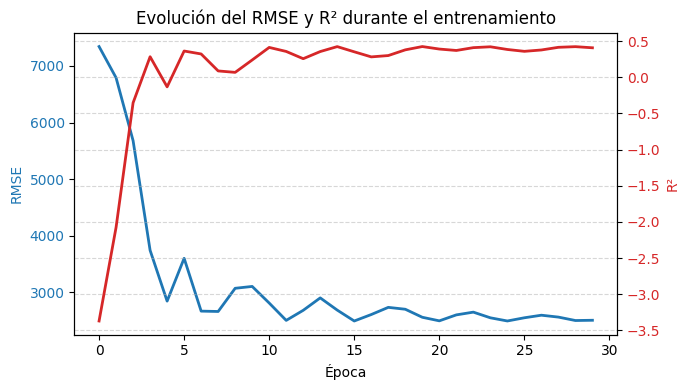

In [397]:
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(loss_hist, color='tab:blue', label='RMSE', linewidth=2)
ax1.set_xlabel("Época")
ax1.set_ylabel("RMSE", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(r2_hist, color='tab:red', label='R²', linewidth=2)
ax2.set_ylabel("R²", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title("Evolución del RMSE y R² durante el entrenamiento")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


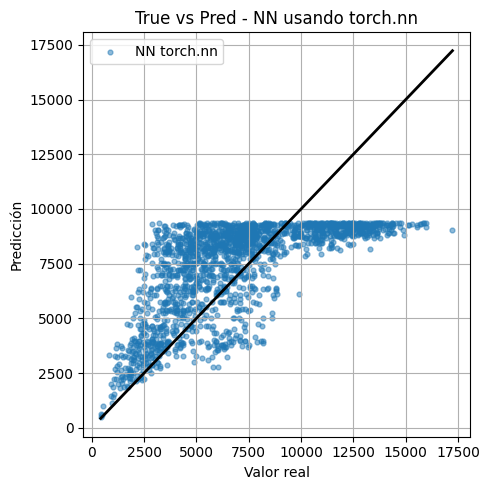

In [ ]:
# 2. Gráfica True vs Pred
plt.figure(figsize=(5,5))
plt.scatter(y_true_np, y_pred_np, s=12, alpha=0.5, label="NN torch.nn")
m = float(min(y_true_np.min(), y_pred_np.min()))
M = float(max(y_true_np.max(), y_pred_np.max()))
plt.plot([m, M], [m, M], linewidth=2, color="black")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("True vs Pred - NN usando torch.nn")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<br>De este gráfico y del valor elevado de RMSE que obtuvimos, lo que podemos observar es que el modelo no está aprendiendo correctamente a preecir nuestro target (no sigue la relación "ideal" que representa la recta de color negro)<br>
<br>Dada esta situación, podemos ajustar de nuestro modelo: <ul><li>Cantidad de épocas</li><li>Learning rate</li><li>Función de activación</li><li>Tamaño del batch</li></ul></br>
<br>Si prestamos atención, lo que pareciera estar sucediendo es que estamos en un caso de "under-fitting": el modelo no está pudiendo aprender los patrones de los datos para estimar correctamene.Por lo tanto las acciones que podríamos tomar respecto de los parámetros mencionados son: <ul><li>Cantidad de épocas: aumnetar</li><li>Learning rate: disminuir</li><li>Función de activación: cambiar a función más compleja</li><li>Tamaño del batch: disminuír</li></ul></br>

In [402]:
#Model definition
#as a start, we use ReLU activation function. We can change it later on, if the results are not good enough
model = nn.Sequential(
    #input layer
    nn.Linear(input_neurons, 32),
    nn.ReLU(),
    #hiden layer #1
    nn.Linear(32, 64),
    nn.ReLU(),
    #hiden layer #2
    nn.Linear(64, 64),
    nn.ReLU(),
    #hiden layer #3
    nn.Linear(64, 32),
    nn.ReLU(),
    #Output layer
    nn.Linear(32, 1),
).to(device)

#define lr
lr = 0.001
#define batch size (for full batch, equals number of sambles)
batch_size = len(X)
#set epochs number
epochs = 50

ds = TensorDataset(X_train, y_train)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

#set optimization funcion to Adam
opt = torch.optim.Adam(model.parameters(), lr=lr)
#set loss function (MSE). Pytorch doesn't have RMSLoss function implemented
mse_loss = nn.MSELoss()

Adam full-batch with torch.nn  RMSE=2862.6931  R2=0.2610  device=cpu


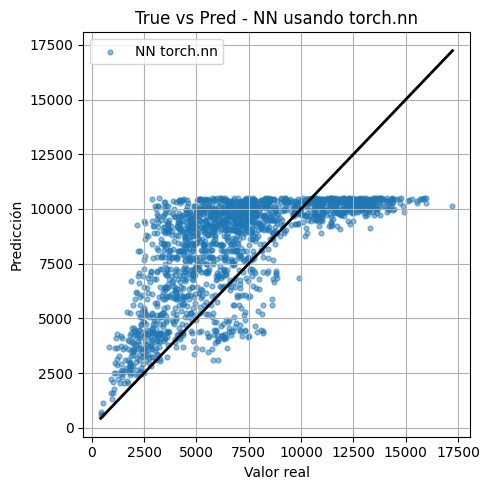

In [403]:
#Model training

#set model in train mode
model.train()

#list to plot the evolution of the model
loss_hist = []
r2_hist = []
i = 0

#epoch loop
for epoch in range(epochs):
    epoch_loss = 0
    #batch loop
    for xb, yb in dl:
        i+=1
        #forward step
        yhat = model(xb)
        #compute the RMSE with our ground truht and our predicted data
        loss = torch.sqrt(mse_loss(yhat, yb)) 

        #reset gradient
        opt.zero_grad(set_to_none=True)
        #set starting point for the backpropagation (we start from the error value, and go backwards from there)
        loss.backward()
        #variable (ws and bs) actualization
        opt.step()
        #accumulate all the epoch loss
        epoch_loss += loss.item()

    #compute the mean epoch loss and store it for plot later
    epoch_loss /= len(dl)
    loss_hist.append(epoch_loss)

    # Compute R² by epoch
    model.eval()
    with torch.no_grad():
        yhat_test = model(X_test)
        y_true_np = y_test.view(-1).cpu().numpy()
        y_pred_np = yhat_test.view(-1).cpu().numpy()
        r2 = r2_score(y_true_np, y_pred_np)
        r2_hist.append(r2)
    model.train()

#set model to eval, and get the score and eval loss
model.eval()
with torch.no_grad():
    yhat = model(X_test)
    mse = mse_loss(yhat, y_test).item()
    rmse = mse ** 0.5
    y_true_np = y_test.view(-1).cpu().numpy()
    y_pred_np = yhat.view(-1).cpu().numpy()
    r2 = r2_score(y_true_np, y_pred_np)

print(f"Adam full-batch with torch.nn  RMSE={rmse:.4f}  R2={r2:.4f}  device={device}")

# 2. Gráfica True vs Pred
plt.figure(figsize=(5,5))
plt.scatter(y_true_np, y_pred_np, s=12, alpha=0.5, label="NN torch.nn")
m = float(min(y_true_np.min(), y_pred_np.min()))
M = float(max(y_true_np.max(), y_pred_np.max()))
plt.plot([m, M], [m, M], linewidth=2, color="black")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("True vs Pred - NN usando torch.nn")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

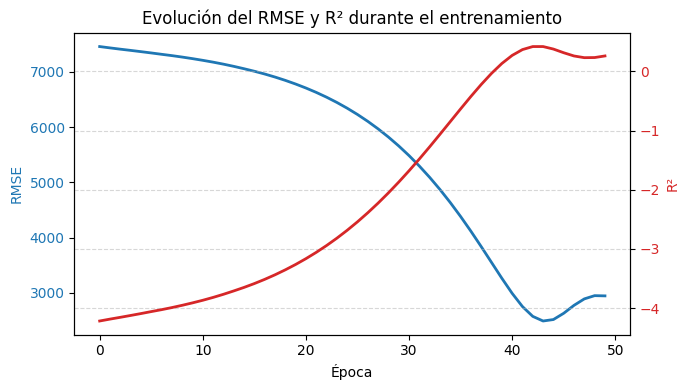

In [ ]:
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(loss_hist, color='tab:blue', label='RMSE', linewidth=2)
ax1.set_xlabel("Época")
ax1.set_ylabel("RMSE", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(r2_hist, color='tab:red', label='R²', linewidth=2)
ax2.set_ylabel("R²", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title("Evolución del RMSE y R² durante el entrenamiento")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<br>Vemos que el modelo emperó disminuyendo el lr a 0.001 y utilizando un número de épocas igual a 50</br>
<br>Se realizará un intento más, aumentando el número de épocas</br>

In [ ]:
#Model definition
#as a start, we use ReLU activation function. We can change it later on, if the results are not good enough
model = nn.Sequential(
    #input layer
    nn.Linear(input_neurons, 32),
    nn.ReLU(),
    #hiden layer #1
    nn.Linear(32, 64),
    nn.ReLU(),
    #hiden layer #2
    nn.Linear(64, 64),
    nn.ReLU(),
    #hiden layer #3
    nn.Linear(64, 32),
    nn.ReLU(),
    #Output layer
    nn.Linear(32, 1),
).to(device)

#define lr
lr = 0.001
#define batch size (for full batch, equals number of sambles)
batch_size = len(X)
#set epochs number
epochs = 150

ds = TensorDataset(X_train, y_train)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

#set optimization funcion to Adam
opt = torch.optim.Adam(model.parameters(), lr=lr)
#set loss function (MSE). Pytorch doesn't have RMSLoss function implemented
mse_loss = nn.MSELoss()

In [419]:
#Model training

#set model in train mode
model.train()

#list to plot the evolution of the model
loss_hist = []
r2_hist = []
i = 0

#epoch loop
for epoch in range(epochs):
    epoch_loss = 0
    #batch loop
    for xb, yb in dl:
        i+=1
        #forward step
        yhat = model(xb)
        #compute the RMSE with our ground truht and our predicted data
        loss = torch.sqrt(mse_loss(yhat, yb)) 

        #reset gradient
        opt.zero_grad(set_to_none=True)
        #set starting point for the backpropagation (we start from the error value, and go backwards from there)
        loss.backward()
        #variable (ws and bs) actualization
        opt.step()
        #accumulate all the epoch loss
        epoch_loss += loss.item()

    #compute the mean epoch loss and store it for plot later
    epoch_loss /= len(dl)
    loss_hist.append(epoch_loss)

    # Compute R² by epoch
    model.eval()
    with torch.no_grad():
        yhat_test = model(X_test)
        y_true_np = y_test.view(-1).cpu().numpy()
        y_pred_np = yhat_test.view(-1).cpu().numpy()
        r2 = r2_score(y_true_np, y_pred_np)
        r2_hist.append(r2)
    model.train()

#set model to eval, and get the score and eval loss
model.eval()
with torch.no_grad():
    yhat = model(X_test)
    mse = mse_loss(yhat, y_test).item()
    rmse = mse ** 0.5
    y_true_np = y_test.view(-1).cpu().numpy()
    y_pred_np = yhat.view(-1).cpu().numpy()
    r2 = r2_score(y_true_np, y_pred_np)

print(f"Adam full-batch with torch.nn  RMSE={rmse:.4f}  R2={r2:.4f}  device={device}")



Adam full-batch with torch.nn  RMSE=2526.4440  R2=0.4244  device=cpu


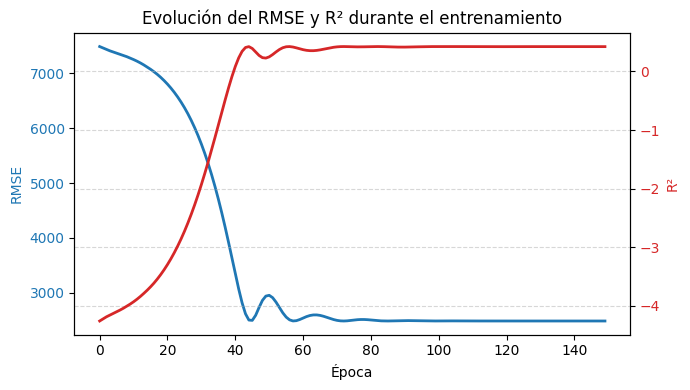

In [408]:
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(loss_hist, color='tab:blue', label='RMSE', linewidth=2)
ax1.set_xlabel("Época")
ax1.set_ylabel("RMSE", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(r2_hist, color='tab:red', label='R²', linewidth=2)
ax2.set_ylabel("R²", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title("Evolución del RMSE y R² durante el entrenamiento")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

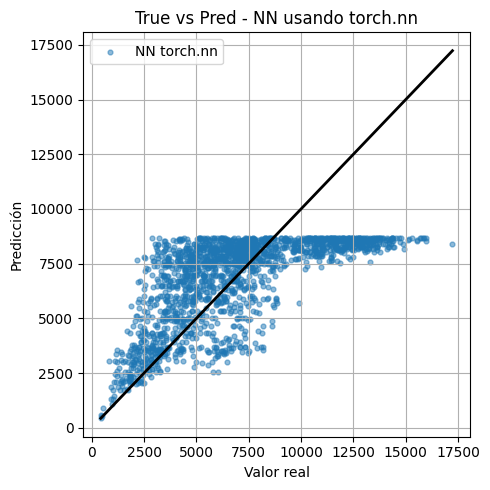

In [409]:
# 2. Gráfica True vs Pred
plt.figure(figsize=(5,5))
plt.scatter(y_true_np, y_pred_np, s=12, alpha=0.5, label="NN torch.nn")
m = float(min(y_true_np.min(), y_pred_np.min()))
M = float(max(y_true_np.max(), y_pred_np.max()))
plt.plot([m, M], [m, M], linewidth=2, color="black")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("True vs Pred - NN usando torch.nn")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<br>Vemos que aún incrementando el número de epocas, no es suficiente (aunque en este caso el RMSE sí dismiuyó)</br>

In [432]:
#Model definition
#as a start, we use ReLU activation function. We can change it later on, if the results are not good enough
model = nn.Sequential(
    #input layer
    nn.Linear(input_neurons, 32),
    nn.LeakyReLU(),
    #hiden layer #1
    nn.Linear(32, 64),
    nn.LeakyReLU(),
    #hiden layer #2
    nn.Linear(64, 64),
    nn.LeakyReLU(),
    #hiden layer #3
    nn.Linear(64, 32),
    nn.LeakyReLU(),
    #Output layer
    nn.Linear(32, 1),
).to(device)

#define lr
lr = 0.001
#define batch size (for full batch, equals number of sambles)
batch_size = int(len(X)/20)
#set epochs number
epochs = 40

ds = TensorDataset(X_train, y_train)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

#set optimization funcion to Adam
opt = torch.optim.Adam(model.parameters(), lr=lr)
#set loss function (MSE). Pytorch doesn't have RMSLoss function implemented
mse_loss = nn.MSELoss()

In [433]:
#Model training
#set model in train mode
model.train()

#list to plot the evolution of the model
loss_hist = []
r2_hist = []
i = 0

#epoch loop
for epoch in range(epochs):
    epoch_loss = 0
    #batch loop
    for xb, yb in dl:
        i+=1
        #forward step
        yhat = model(xb)
        #compute the RMSE with our ground truht and our predicted data
        loss = torch.sqrt(mse_loss(yhat, yb)) 

        #reset gradient
        opt.zero_grad(set_to_none=True)
        #set starting point for the backpropagation (we start from the error value, and go backwards from there)
        loss.backward()
        #variable (ws and bs) actualization
        opt.step()
        #accumulate all the epoch loss
        epoch_loss += loss.item()

    #compute the mean epoch loss and store it for plot later
    epoch_loss /= len(dl)
    loss_hist.append(epoch_loss)

    # Compute R² by epoch
    model.eval()
    with torch.no_grad():
        yhat_test = model(X_test)
        y_true_np = y_test.view(-1).cpu().numpy()
        y_pred_np = yhat_test.view(-1).cpu().numpy()
        r2 = r2_score(y_true_np, y_pred_np)
        r2_hist.append(r2)
    model.train()

#set model to eval, and get the score and eval loss
model.eval()
with torch.no_grad():
    yhat = model(X_test)
    mse = mse_loss(yhat, y_test).item()
    rmse = mse ** 0.5
    y_true_np = y_test.view(-1).cpu().numpy()
    y_pred_np = yhat.view(-1).cpu().numpy()
    r2 = r2_score(y_true_np, y_pred_np)

print(f"Adam full-batch with torch.nn  RMSE={rmse:.4f}  R2={r2:.4f}  device={device}")

Adam full-batch with torch.nn  RMSE=2552.3801  R2=0.4125  device=cpu


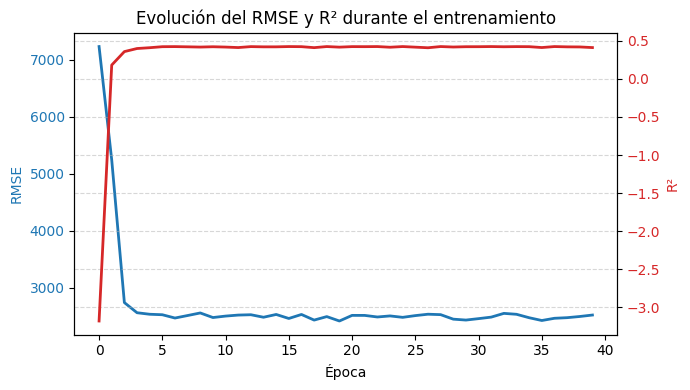

In [434]:
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(loss_hist, color='tab:blue', label='RMSE', linewidth=2)
ax1.set_xlabel("Época")
ax1.set_ylabel("RMSE", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(r2_hist, color='tab:red', label='R²', linewidth=2)
ax2.set_ylabel("R²", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title("Evolución del RMSE y R² durante el entrenamiento")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<br>El error disminuye rápido en las primeras épocas, pero llega a una meseta y no disminuye más.



<br>Podríamos pensar que existen dos alternativas: <ul><li>Los datos desarrollados en el EDA no son suficientemente buenos</il><li>El modelo no posee la complejidad suficiente para extraer los patrones necesarios (lo cuál, es más improbable)</il>

Aunque sea más improbable que la cantidad de capas o neuronas no sea suficiente, se realizará una prueba más, agregando una capa oculta

<br>Observando el resultado obtenido al agregar una capa más al modelo, vemos que no ha mejorado. Por lo tanto, podemos descartar esta hipótesis y concluír que se deben revisar las variables geneardas en el EDA.</br><br>A continuación, como una prueba para trabajar sobre los datos, se realizará una prueba normalizando el dataset

In [ ]:
# Normalización min max
X = X.to_numpy()
y = y.to_numpy()

x_norm = (X - np.min(X, axis=0)) / (np.max(X, axis=0 ) - np.min(X, axis=0))
y_norm = (y - np.min(y, axis=0)) / (np.max(y, axis=0 ) - np.min(y, axis=0))


X_tensor_norm = torch.tensor(x_norm,dtype=torch.float32)
y_tensor_norm = torch.tensor(y_norm,dtype=torch.float32)

#Split out dataset on Train and test
X_train, X_test, y_train, y_test = train_test_split(X_tensor_norm, y_tensor_norm, test_size=0.25, random_state=42)
X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)

#define number of input neurons
input_neurons = 25

In [512]:
#Model definition
#as a start, we use ReLU activation function. We can change it later on, if the results are not good enough
model = nn.Sequential(
    #input layer
    nn.Linear(25, 32),
    nn.LeakyReLU(),
    #hiden layer #1
    nn.Linear(32, 64),
    nn.LeakyReLU(),
    #hiden layer #2
    nn.Linear(64,128),
    nn.LeakyReLU(),
    #hiden layer #3
    nn.Linear(128, 32),
    nn.LeakyReLU(),
    #hiden layer #4
    nn.Linear(32, 32),
    nn.LeakyReLU(),
    #Output layer
    nn.Linear(32, 1),
).to(device)

#define lr
lr = 0.0001
#define batch size (for full batch, equals number of sambles)
batch_size = int(len(X)/40)
#set epochs number
epochs = 40

ds = TensorDataset(X_train, y_train)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

#set optimization funcion to Adam
opt = torch.optim.Adam(model.parameters(), lr=lr)
#set loss function (MSE). Pytorch doesn't have RMSLoss function implemented
mse_loss = nn.MSELoss()

In [ ]:
#Model training
#set model in train mode
model.train()

#list to plot the evolution of the model
loss_hist = []
r2_hist = []
i = 0

#epoch loop
for epoch in range(epochs):
    epoch_loss = 0
    #batch loop
    for xb, yb in dl:
        i+=1
        #forward step
        yhat = model(xb)
        #compute the RMSE with our ground truht and our predicted data
        #loss = torch.sqrt(mse_loss(yhat, yb)) 
        loss = mse_loss(yhat, yb)

        #reset gradient
        opt.zero_grad(set_to_none=True)
        #set starting point for the backpropagation (we start from the error value, and go backwards from there)
        loss.backward()
        #variable (ws and bs) actualization
        opt.step()
        #accumulate all the epoch loss
        epoch_loss += loss.item()

    #compute the mean epoch loss and store it for plot later
    epoch_loss /= len(dl)
    loss_hist.append(epoch_loss)

    # Compute R² by epoch
    model.eval()
    with torch.no_grad():
        yhat_test = model(X_test)
        y_true_np = y_test.view(-1).cpu().numpy()
        y_pred_np = yhat_test.view(-1).cpu().numpy()
        r2 = r2_score(y_true_np, y_pred_np)
        r2_hist.append(r2)
    model.train()

#set model to eval, and get the score and eval loss
model.eval()
with torch.no_grad():
    yhat = model(X_test)
    mse = mse_loss(yhat, y_test).item()
    rmse = mse ** 0.5
    y_true_np = y_test.view(-1).cpu().numpy()
    y_pred_np = yhat.view(-1).cpu().numpy()
    r2 = r2_score(y_true_np, y_pred_np)

print(f"Adam mini-batch with torch.nn  RMSE={rmse:.4f}  R2={r2:.4f}  device={device}")

Adam full-batch with torch.nn  RMSE=0.1070  R2=0.7031  device=cpu


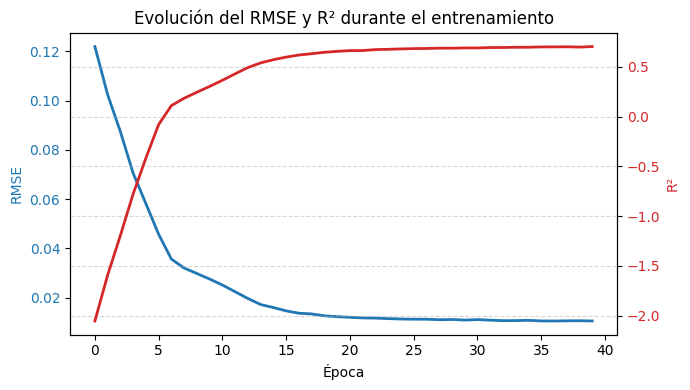

In [514]:
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(loss_hist, color='tab:blue', label='RMSE', linewidth=2)
ax1.set_xlabel("Época")
ax1.set_ylabel("RMSE", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(r2_hist, color='tab:red', label='R²', linewidth=2)
ax2.set_ylabel("R²", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title("Evolución del RMSE y R² durante el entrenamiento")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

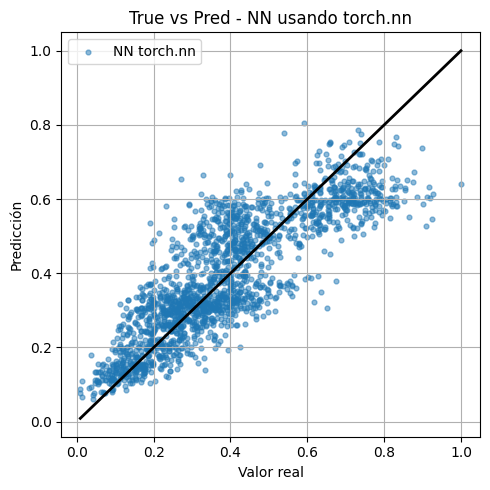

In [515]:
# 2. Gráfica True vs Pred
plt.figure(figsize=(5,5))
plt.scatter(y_true_np, y_pred_np, s=12, alpha=0.5, label="NN torch.nn")
m = float(min(y_true_np.min(), y_pred_np.min()))
M = float(max(y_true_np.max(), y_pred_np.max()))
plt.plot([m, M], [m, M], linewidth=2, color="black")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("True vs Pred - NN usando torch.nn")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<br>Observamos que con la normalización, el modelo mejoró el R^2 y también pudo minimizar el RMSE, produciendo un resultado que se acerca mucho más al deseado

### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

In [ ]:
# Normalización min max
X = X.to_numpy()
y = y.to_numpy()

x_norm = (X - np.min(X, axis=0)) / (np.max(X, axis=0 ) - np.min(X, axis=0))
y_norm = (y - np.min(y, axis=0)) / (np.max(y, axis=0 ) - np.min(y, axis=0))


X_tensor_norm = torch.tensor(x_norm,dtype=torch.float32)
y_tensor_norm = torch.tensor(y_norm,dtype=torch.float32)

#Split out dataset on Train and test
X_train, X_test, y_train, y_test = train_test_split(X_tensor_norm, y_tensor_norm, test_size=0.25, random_state=42)
X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)

#define number of input neurons
input_neurons = 25

In [533]:
#Model definition
#as a start, we use ReLU activation function. We can change it later on, if the results are not good enough
model = nn.Sequential(
    #input layer
    nn.Linear(25, 32),
    nn.LeakyReLU(),
    #hiden layer #1
    nn.Linear(32, 64),
    nn.LeakyReLU(),
    #hiden layer #2
    nn.Linear(64,128),
    nn.LeakyReLU(),
    #hiden layer #3
    nn.Linear(128, 32),
    nn.LeakyReLU(),
    #hiden layer #4
    nn.Linear(32, 32),
    nn.LeakyReLU(),
    #Output layer
    nn.Linear(32, 1),
).to(device)

#define lr
lr = 0.0001
#define batch size (for full batch, equals number of sambles)
batch_size = int(len(X)/40)
#set epochs number
epochs = 40

ds = TensorDataset(X_train, y_train)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

#set optimization funcion to Adam
opt = torch.optim.Adam(model.parameters(), lr=lr)
#set loss function (MSE). Pytorch doesn't have RMSLoss function implemented
mse_loss = nn.MSELoss()

In [534]:
#Model training
#set model in train mode
model.train()

#list to plot the evolution of the model
loss_train_hist = []
r2_train_hist = []
loss_test_hist = []
r2_test_hist = []


#epoch loop
for epoch in range(epochs):
    epoch_loss = 0
    epoch_r2 = 0
    train_r2 = 0
    #batch loop
    for xb, yb in dl:
        #forward step
        yhat = model(xb)
        #compute the RMSE with our ground truht and our predicted data
        loss = torch.sqrt(mse_loss(yhat, yb)) 
        #loss = mse_loss(yhat, yb)

        #reset gradient
        opt.zero_grad(set_to_none=True)
        #set starting point for the backpropagation (we start from the error value, and go backwards from there)
        loss.backward()
        #variable (ws and bs) actualization
        opt.step()
        #accumulate all the epoch loss
        epoch_loss += loss.item()


        y_true_train = yb.view(-1).cpu().numpy()
        y_hat = yhat.view(-1).cpu().detach().numpy()
        train_r2 = r2_score(y_true_train, y_hat)
        epoch_r2+=train_r2 

    #compute the mean epoch loss and store it for plot later
    epoch_loss /= len(dl)
    loss_train_hist.append(epoch_loss)

    #compute the r2 for the train dataset
    epoch_r2 /= len(dl)
    r2_train_hist.append(epoch_r2)

    # Compute R² by epoch for the validation dataset
    model.eval()
    with torch.no_grad():
        yhat_test = model(X_test)
        loss_test = torch.sqrt(mse_loss(yhat_test, y_test))
        loss_test_hist.append(loss_test.item())

        y_true_np = y_test.view(-1).cpu().numpy()
        y_pred_np = yhat_test.view(-1).cpu().numpy()
        r2 = r2_score(y_true_np, y_pred_np)
        r2_test_hist.append(r2)

        
    model.train()

#set model to eval, and get the score and eval loss
model.eval()
with torch.no_grad():
    yhat = model(X_test)
    mse = mse_loss(yhat, y_test).item()
    rmse = mse ** 0.5
    y_true_np = y_test.view(-1).cpu().numpy()
    y_pred_np = yhat.view(-1).cpu().numpy()
    r2 = r2_score(y_true_np, y_pred_np)

print(f"Adam full-batch with torch.nn  RMSE={rmse:.4f}  R2={r2:.4f}  device={device}")

Adam full-batch with torch.nn  RMSE=0.1065  R2=0.7059  device=cpu


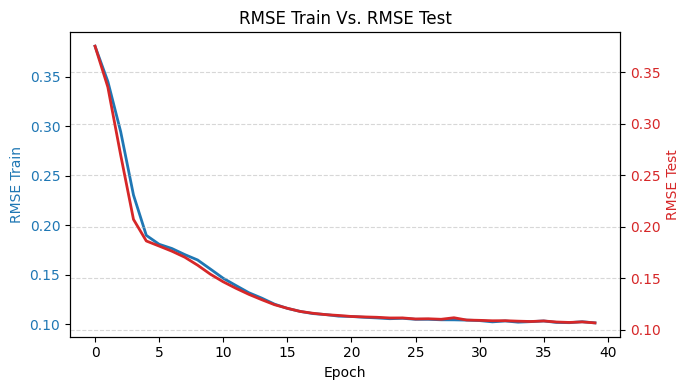

In [535]:
fig, ax1 = plt.subplots(figsize=(7,4))
#Plot train loss
ax1.plot(loss_train_hist, color='tab:blue', label='RMSE Train', linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("RMSE Train", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
#plot the test loss
ax2.plot(loss_test_hist, color='tab:red', label='RMSE Test', linewidth=2)
ax2.set_ylabel("RMSE Test", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("RMSE Train Vs. RMSE Test")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

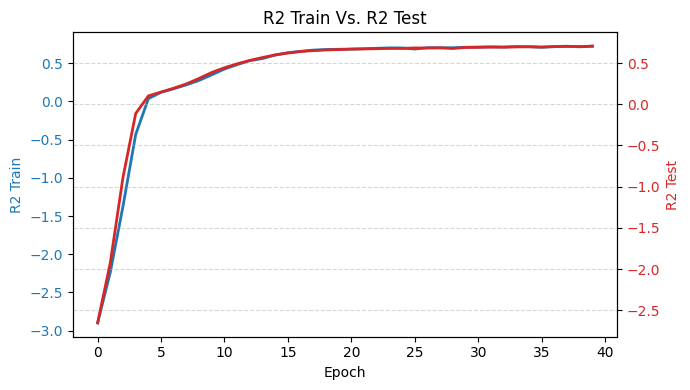

In [536]:
fig, ax1 = plt.subplots(figsize=(7,4))
#Plot train loss
ax1.plot(r2_train_hist, color='tab:blue', label='R2 Train', linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("R2 Train", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
#plot the test loss
ax2.plot(r2_test_hist, color='tab:red', label='R2 Test', linewidth=2)
ax2.set_ylabel("R2 Test", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("R2 Train Vs. R2 Test")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

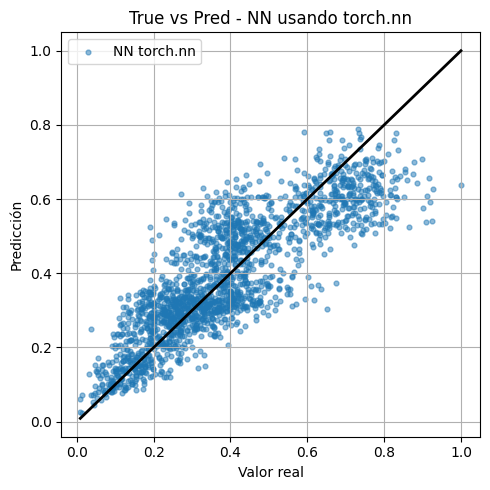

In [537]:
plt.figure(figsize=(5,5))
plt.scatter(y_true_np, y_pred_np, s=12, alpha=0.5, label="NN torch.nn")
m = float(min(y_true_np.min(), y_pred_np.min()))
M = float(max(y_true_np.max(), y_pred_np.max()))
plt.plot([m, M], [m, M], linewidth=2, color="black")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("True vs Pred - NN usando torch.nn")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<br>En el apartado <b>2b)</b> podemos observar el proceso de iteración. En conclusión, frente al underfitting sufrido por el modelo en una primera instancia, se encontró que no se debía ajustar más la complejidad del modelo, sino que la mayor diferencia se logró trabajando sobre los datos, específicamente realizando una normalización de los mismos.</br><br>Remitiéndonos al apartado <b>1</b> de este mismo trabajo práctico, se observó una situación similar cuando la función objetivo que se deseaba que el modelo pudiera aprender generaba valores de ground truth "muy altos" (siendo que el modelo sólo podía generar valores entre -1 y 1): el modelo no podía generar dichos valores y sufría un under-fitting. En última instancia los resultados obtenidos parecen remarcar la importancia de realizar una normalización de los datos, ya que esto ayuda al modelo a aprender</br>

### 2d) Conclusiones finales (0.5 puntos)
Redactar de manera detallada las conclusiones finales y si se cumplió con el objetivo o no.

<br>Se verifica que se ha cumplido la meta de lograr un modelo con, al menos, un R2 de 0.7, corrigiendo el "under-fitting" que sufría el model en las primeras iteraciones. En este caso, hemos observado que la limitáción al aprendizaje del modelo, no estaba en el modelo en sí, si no en los datos que estaban siendo suministrados mismos. Se destaca la importancia del paso de normalización, omitido en las primeras iteraciones, pero responsable en gran medida de mejorar el ajuste del modelo.</br>

<br>Una prueba más que podríamos plantearnos incluso es, habiendo incorporado la normalización ¿Puede el modelo ser más simple? A continuación, se quita una capa (capa oculta cuatro) y se achica el número máximo de neuronas por capa utilizadas de 128 a 64. Además, pasamos de LeakyReLU a ReLU para la función de activación:

In [546]:
#Model definition
#as a start, we use ReLU activation function. We can change it later on, if the results are not good enough
model = nn.Sequential(
    #input layer
    nn.Linear(25, 32),
    nn.ReLU(),
    #hiden layer #1
    nn.Linear(32, 64),
    nn.ReLU(),
    #hiden layer #2
    nn.Linear(64,64),
    nn.ReLU(),
    #hiden layer #3
    nn.Linear(64, 32),
    nn.ReLU(),
    #Output layer
    nn.Linear(32, 1),
).to(device)

#define lr
lr = 0.0001
#define batch size (for full batch, equals number of sambles)
batch_size = int(len(X)/40)
#set epochs number
epochs = 50

ds = TensorDataset(X_train, y_train)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

#set optimization funcion to Adam
opt = torch.optim.Adam(model.parameters(), lr=lr)
#set loss function (MSE). Pytorch doesn't have RMSLoss function implemented
mse_loss = nn.MSELoss()

In [547]:
#Model training
#set model in train mode
model.train()

#list to plot the evolution of the model
loss_train_hist = []
r2_train_hist = []
loss_test_hist = []
r2_test_hist = []


#epoch loop
for epoch in range(epochs):
    epoch_loss = 0
    epoch_r2 = 0
    train_r2 = 0
    #batch loop
    for xb, yb in dl:
        #forward step
        yhat = model(xb)
        #compute the RMSE with our ground truht and our predicted data
        loss = torch.sqrt(mse_loss(yhat, yb)) 
        #loss = mse_loss(yhat, yb)

        #reset gradient
        opt.zero_grad(set_to_none=True)
        #set starting point for the backpropagation (we start from the error value, and go backwards from there)
        loss.backward()
        #variable (ws and bs) actualization
        opt.step()
        #accumulate all the epoch loss
        epoch_loss += loss.item()


        y_true_train = yb.view(-1).cpu().numpy()
        y_hat = yhat.view(-1).cpu().detach().numpy()
        train_r2 = r2_score(y_true_train, y_hat)
        epoch_r2+=train_r2 

    #compute the mean epoch loss and store it for plot later
    epoch_loss /= len(dl)
    loss_train_hist.append(epoch_loss)

    #compute the r2 for the train dataset
    epoch_r2 /= len(dl)
    r2_train_hist.append(epoch_r2)

    # Compute R² by epoch for the validation dataset
    model.eval()
    with torch.no_grad():
        yhat_test = model(X_test)
        loss_test = torch.sqrt(mse_loss(yhat_test, y_test))
        loss_test_hist.append(loss_test.item())

        y_true_np = y_test.view(-1).cpu().numpy()
        y_pred_np = yhat_test.view(-1).cpu().numpy()
        r2 = r2_score(y_true_np, y_pred_np)
        r2_test_hist.append(r2)

        
    model.train()

#set model to eval, and get the score and eval loss
model.eval()
with torch.no_grad():
    yhat = model(X_test)
    mse = mse_loss(yhat, y_test).item()
    rmse = mse ** 0.5
    y_true_np = y_test.view(-1).cpu().numpy()
    y_pred_np = yhat.view(-1).cpu().numpy()
    r2 = r2_score(y_true_np, y_pred_np)

print(f"Adam full-batch with torch.nn  RMSE={rmse:.4f}  R2={r2:.4f}  device={device}")

Adam full-batch with torch.nn  RMSE=0.1058  R2=0.7099  device=cpu


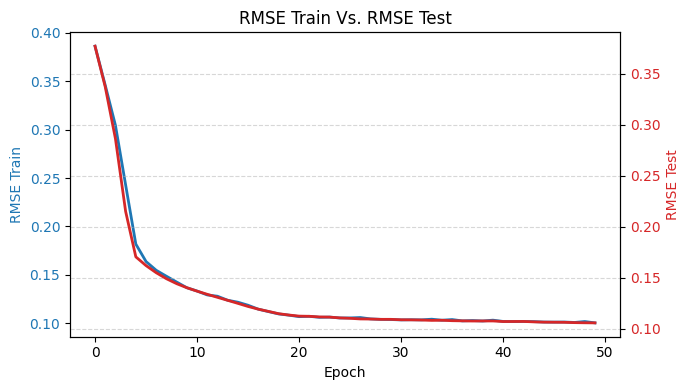

In [ ]:
fig, ax1 = plt.subplots(figsize=(7,4))
#Plot train loss
ax1.plot(loss_train_hist, color='tab:blue', label='RMSE Train', linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("RMSE Train", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
#plot the test loss
ax2.plot(loss_test_hist, color='tab:red', label='RMSE Test', linewidth=2)
ax2.set_ylabel("RMSE Test", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("RMSE Train Vs. RMSE Test")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

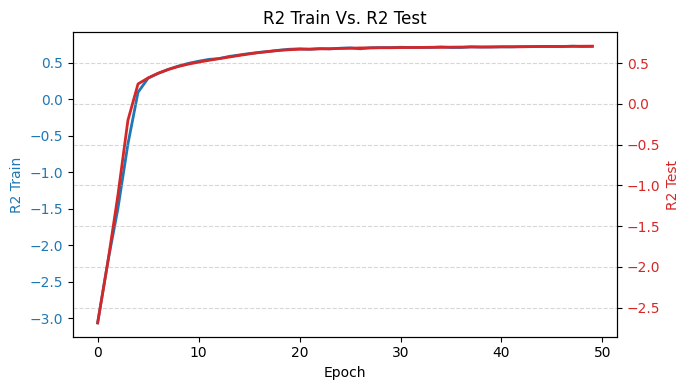

In [549]:
fig, ax1 = plt.subplots(figsize=(7,4))
#Plot train loss
ax1.plot(r2_train_hist, color='tab:blue', label='R2 Train', linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("R2 Train", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
#plot the test loss
ax2.plot(r2_test_hist, color='tab:red', label='R2 Test', linewidth=2)
ax2.set_ylabel("R2 Test", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("R2 Train Vs. R2 Test")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

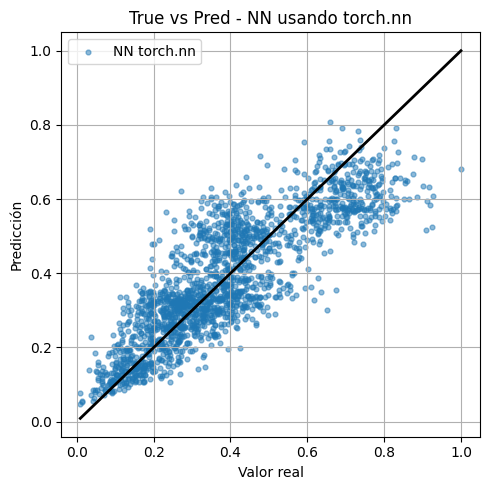

In [550]:
plt.figure(figsize=(5,5))
plt.scatter(y_true_np, y_pred_np, s=12, alpha=0.5, label="NN torch.nn")
m = float(min(y_true_np.min(), y_pred_np.min()))
M = float(max(y_true_np.max(), y_pred_np.max()))
plt.plot([m, M], [m, M], linewidth=2, color="black")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("True vs Pred - NN usando torch.nn")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<br>Vemos que podemos lograr con un modelo mucho más simple (menos capas, menos neuronas y función de activación ReLU) una performance similar a la que teníamos en el punto anterior. Esto nos demuestra la importancia de los datos que utilizamos para entrenar: <b>un modelo, nunca podrá ser mejor que los datos con los que es entrenado</b>

<br><b>Si además, subimos el learning rate:

In [ ]:
#Model definition
#as a start, we use ReLU activation function. We can change it later on, if the results are not good enough
model = nn.Sequential(
    #input layer
    nn.Linear(25, 32),
    nn.ReLU(),
    #hiden layer #1
    nn.Linear(32, 64),
    nn.ReLU(),
    #hiden layer #2
    nn.Linear(64,64),
    nn.ReLU(),
    #hiden layer #3
    nn.Linear(64, 32),
    nn.ReLU(),
    #Output layer
    nn.Linear(32, 1),
).to(device)

#define lr
lr = 0.001
#define batch size (for full batch, equals number of sambles)
batch_size = int(len(X)/40)
#set epochs number
epochs = 70

ds = TensorDataset(X_train, y_train)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

#set optimization funcion to Adam
opt = torch.optim.Adam(model.parameters(), lr=lr)
#set loss function (MSE). Pytorch doesn't have RMSLoss function implemented
mse_loss = nn.MSELoss()

In [559]:
#Model training
#set model in train mode
model.train()

#list to plot the evolution of the model
loss_train_hist = []
r2_train_hist = []
loss_test_hist = []
r2_test_hist = []


#epoch loop
for epoch in range(epochs):
    epoch_loss = 0
    epoch_r2 = 0
    train_r2 = 0
    #batch loop
    for xb, yb in dl:
        #forward step
        yhat = model(xb)
        #compute the RMSE with our ground truht and our predicted data
        loss = torch.sqrt(mse_loss(yhat, yb)) 
        #loss = mse_loss(yhat, yb)

        #reset gradient
        opt.zero_grad(set_to_none=True)
        #set starting point for the backpropagation (we start from the error value, and go backwards from there)
        loss.backward()
        #variable (ws and bs) actualization
        opt.step()
        #accumulate all the epoch loss
        epoch_loss += loss.item()


        y_true_train = yb.view(-1).cpu().numpy()
        y_hat = yhat.view(-1).cpu().detach().numpy()
        train_r2 = r2_score(y_true_train, y_hat)
        epoch_r2+=train_r2 

    #compute the mean epoch loss and store it for plot later
    epoch_loss /= len(dl)
    loss_train_hist.append(epoch_loss)

    #compute the r2 for the train dataset
    epoch_r2 /= len(dl)
    r2_train_hist.append(epoch_r2)

    # Compute R² by epoch for the validation dataset
    model.eval()
    with torch.no_grad():
        yhat_test = model(X_test)
        loss_test = torch.sqrt(mse_loss(yhat_test, y_test))
        loss_test_hist.append(loss_test.item())

        y_true_np = y_test.view(-1).cpu().numpy()
        y_pred_np = yhat_test.view(-1).cpu().numpy()
        r2 = r2_score(y_true_np, y_pred_np)
        r2_test_hist.append(r2)

        
    model.train()

#set model to eval, and get the score and eval loss
model.eval()
with torch.no_grad():
    yhat = model(X_test)
    mse = mse_loss(yhat, y_test).item()
    rmse = mse ** 0.5
    y_true_np = y_test.view(-1).cpu().numpy()
    y_pred_np = yhat.view(-1).cpu().numpy()
    r2 = r2_score(y_true_np, y_pred_np)

print(f"Adam full-batch with torch.nn  RMSE={rmse:.4f}  R2={r2:.4f}  device={device}")

Adam full-batch with torch.nn  RMSE=0.1035  R2=0.7223  device=cpu


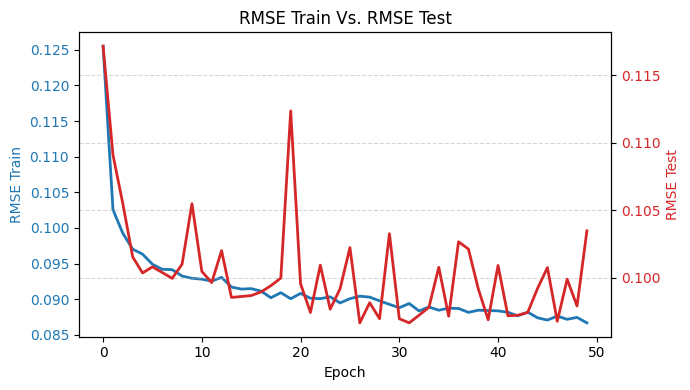

In [560]:
fig, ax1 = plt.subplots(figsize=(7,4))
#Plot train loss
ax1.plot(loss_train_hist, color='tab:blue', label='RMSE Train', linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("RMSE Train", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
#plot the test loss
ax2.plot(loss_test_hist, color='tab:red', label='RMSE Test', linewidth=2)
ax2.set_ylabel("RMSE Test", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("RMSE Train Vs. RMSE Test")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

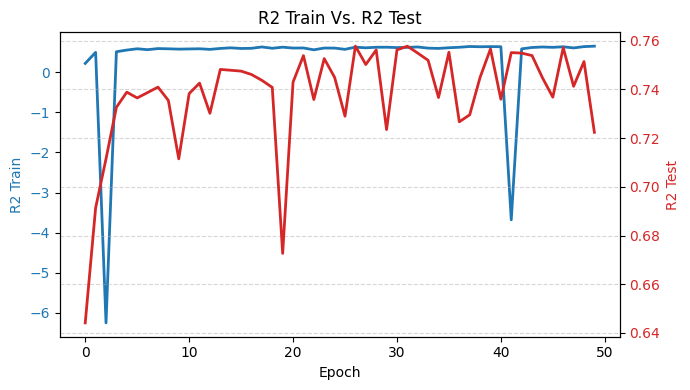

In [561]:
fig, ax1 = plt.subplots(figsize=(7,4))
#Plot train loss
ax1.plot(r2_train_hist, color='tab:blue', label='R2 Train', linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("R2 Train", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
#plot the test loss
ax2.plot(r2_test_hist, color='tab:red', label='R2 Test', linewidth=2)
ax2.set_ylabel("R2 Test", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("R2 Train Vs. R2 Test")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

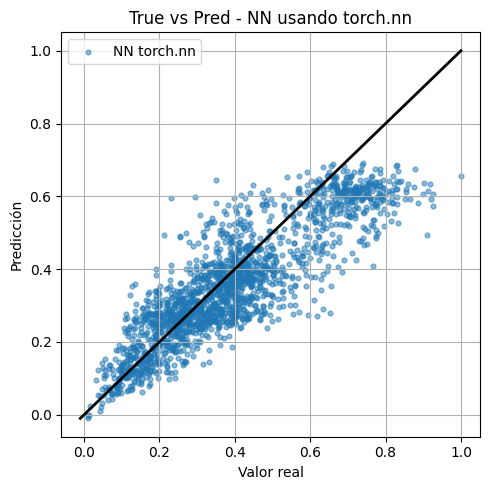

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(y_true_np, y_pred_np, s=12, alpha=0.5, label="NN torch.nn")
m = float(min(y_true_np.min(), y_pred_np.min()))
M = float(max(y_true_np.max(), y_pred_np.max()))
plt.plot([m, M], [m, M], linewidth=2, color="black")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("True vs Pred - NN usando torch.nn")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Vemos que subiendo el learning rate, obtenemos un comportamiento errático sobre los datos de test. Aunque el score final, sea mejor, esto no es un comportamento deseado y podría indicarnos que el learning rate utilizado ocasiona que se den "pasos demasiado grandes" al querer ajustar los parámetros

Respodiendo a las preguntas planteadas:

- Elección de función de activación: mediente pruebas empíricas y por lo ya expresado, se elige ReLU
- Algortimo de optimzación: se encontró que el Adam mini-batch resultó un mejor algoritmo de optimización
- Learning rate: de lo probado, se encuentra que puede utilizarse un lr 0.0001, que es un learning rate bastante bajo, sin embargo llega a ajustar el modelo en las épocas ejecutadas y sin comportamietos erráticos como learing rates mayores
- Analizar cuál sería el mejor número de épocas para entrenar el modelo: de las pruebas realizadas, se encuentra que 40 es un número de épocas suficiente para entrenar este modelo, ya que no se logran mejoras luego de ese período (sin caer en un sub-entrenamiento o entrenamiento incompleto).
